# CSE427 — Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text (SST) Compression
## Final Submission Notebook

**Project:** Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text Compression  
**Course:** CSE427  

### What this notebook does (in order):
1. **Setup** — imports, paths, helpers  
2. **EDA** — question-type & length analysis on GQA sample data  
3. **Text-only baseline** — Bag-of-Words + Logistic Regression (sanity check)  
4. **Toy SST pipeline** — validate SST builder, serializer, filtering, mock reasoner  
5. **Real GQA scene graph preprocessing** — convert GQA val scene graphs → SST  
6. **Large-scale balanced dataset** — build a **15 000-sample** balanced GQA subset  
7. **Full SST + Mistral evaluation** — with checkpointing/resume support  
8. **Ablation study** — Caption, Keyword-Aware, Compact, No-Relations, No-Attrs, Objects-Only  
9. **Statistical analysis** — bootstrap CIs + McNemar paired tests  
10. **LLaVA image baseline** — download images, run LLaVA, evaluate  
11. **SST vs LLaVA comparison** — final tables + error analysis  
12. **Visualisations** — accuracy-token trade-off plots for report  

### Important notes:
- Steps 7 and 10 are **computationally expensive**. 
- The GQA raw data (`val_sceneGraphs.json` and `val_balanced_questions.json`) must be downloaded separately. 



## 0. How to Run This Notebook

### Step-by-step setup (do this once):

```
# 1. Create a Python virtual environment
python3 -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate

# 2. Install dependencies
pip install pandas numpy matplotlib seaborn scikit-learn jupyter notebook \
            requests tqdm tiktoken ollama pillow

# 3. Install and start Ollama  (https://ollama.com)
ollama pull mistral
ollama pull llava

# 4. Download GQA raw data and place files here:
#    data/gqa_raw/val_sceneGraphs.json
#    data/gqa_raw/questions/val_balanced_questions.json
#    Get them from: https://cs.stanford.edu/people/dorarad/gqa/download.html

```

### Folder structure expected:
```
CSE427_SST_Project-main/
├── notebooks/
│   └── cse427_sst_FINAL.ipynb   ← this file
├── data/
│   ├── gqa_raw/
│   │   ├── val_sceneGraphs.json
│   │   └── questions/
│   │       └── val_balanced_questions.json
│   ├── raw/
│   │   └── sample_questions.json
│   └── processed/               ← auto-created
├── outputs/
│   ├── eda/                     ← auto-created
│   └── results/                 ← auto-created
└── requirements.txt
```



## 1. Setup and Imports

In [2]:
import sys, os, json, re, time, random, math
from pathlib import Path
from collections import Counter, defaultdict
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    import tiktoken
    TOKEN_ENCODER = tiktoken.get_encoding("cl100k_base")
    print("tiktoken loaded — using subword token counts")
except Exception:
    TOKEN_ENCODER = None
    print("tiktoken not found — using whitespace token counts (install with: pip install tiktoken)")

try:
    import ollama
    print("ollama package loaded")
except Exception:
    ollama = None
    print("ollama not found — LLM evaluation cells will fail until installed")

try:
    from sklearn.feature_extraction.text import CountVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score
    print("scikit-learn loaded")
except Exception:
    print("scikit-learn not found")

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path("..").resolve()
DATA_DIR       = PROJECT_ROOT / "data"
RAW_DIR        = DATA_DIR / "raw"
GQA_RAW_DIR    = DATA_DIR / "gqa_raw"
PROCESSED_DIR  = DATA_DIR / "processed"
IMAGE_DIR      = DATA_DIR / "gqa_images_subset"
RESULTS_DIR    = PROJECT_ROOT / "outputs" / "results"
EDA_DIR        = PROJECT_ROOT / "outputs" / "eda"

for d in [PROCESSED_DIR, RESULTS_DIR, EDA_DIR, IMAGE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("\nProject root:", PROJECT_ROOT)
print("Results dir:", RESULTS_DIR)


tiktoken not found — using whitespace token counts (install with: pip install tiktoken)
ollama package loaded
scikit-learn loaded

Project root: /Users/alisha/Documents/CSE427_SST_Project
Results dir: /Users/alisha/Documents/CSE427_SST_Project/outputs/results


## 1.2 Global Helper Functions


In [ ]:
# ── Shared helpers (single source of truth) ────────────────────────────────
# All answer-normalisation, SST builders, the keyword-aware filter, prompt
# construction, the Ollama client, and the statistics live in src/sst_eval so
# the three evaluation notebooks cannot drift apart. See that package for docs.
import sys
from pathlib import Path
sys.path.insert(0, str((Path("..") / "src").resolve()))

from sst_eval import *                 # noqa: F401,F403
from sst_eval import METHOD_NAMES

print("Imported shared helpers from sst_eval.")
print("Methods:", METHODS)


## 2. Exploratory Data Analysis (EDA)

Loading a small GQA-style sample and visualising question-type and length distributions.

In [7]:
# ── Load small sample ──────────────────────────────────────────────────────
sample_path = RAW_DIR / "sample_questions.json"

if not sample_path.exists():
    # Generate a tiny synthetic sample so EDA cells always run
    synthetic = {
        f"q{i}": {
            "question": q, "answer": a,
            "types": {"semantic": t},
            "imageId": f"img_{i}"
        }
        for i,(q,a,t) in enumerate([
            ("What color is the bus?","red","attr"),
            ("How many people are there?","3","count"),
            ("Is the dog near the tree?","yes","rel"),
            ("What is on the table?","cup","query"),
            ("What type of vehicle is this?","bus","cat"),
        ])
    }
    sample_path.parent.mkdir(parents=True, exist_ok=True)
    with open(sample_path,"w") as f: json.dump(synthetic, f, indent=2)
    print("Created synthetic sample_questions.json")

with open(sample_path) as f:
    raw = json.load(f)

records = []
for qid, q in raw.items():
    records.append({
        "question_id": qid,
        "question":    q.get("question",""),
        "answer":      q.get("answer",""),
        "semantic_type": q.get("types",{}).get("semantic","unknown") if isinstance(q.get("types"),dict) else "unknown",
    })

eda_df = pd.DataFrame(records)
eda_df["question_length"] = eda_df["question"].str.split().str.len()
print("Loaded", len(eda_df), "samples for EDA")
eda_df.head()


Loaded 3 samples for EDA


,question_id,question,answer,semantic_type,question_length
0,q1,What color is the bus?,red,attribute,5
1,q2,How many people are there?,3,count,5
2,q3,Is the person near the car?,yes,relation,6


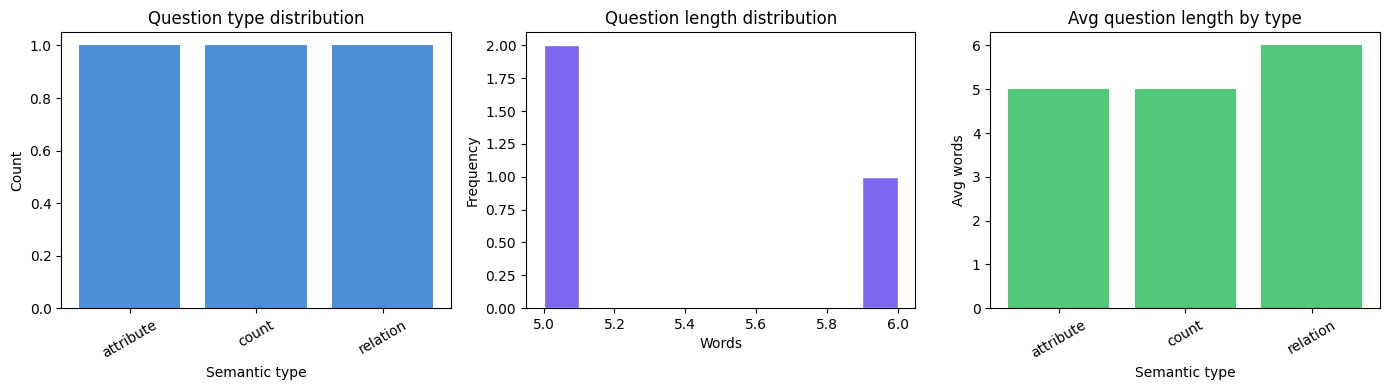

EDA figure saved.


In [8]:
# ── Question-type distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(14,4))

tc = eda_df["semantic_type"].value_counts()
axes[0].bar(tc.index, tc.values, color="#4A90D9")
axes[0].set_title("Question type distribution")
axes[0].set_xlabel("Semantic type"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(eda_df["question_length"], bins=10, color="#7B68EE", edgecolor="white")
axes[1].set_title("Question length distribution")
axes[1].set_xlabel("Words"); axes[1].set_ylabel("Frequency")

gl = eda_df.groupby("semantic_type")["question_length"].mean()
axes[2].bar(gl.index, gl.values, color="#50C878")
axes[2].set_title("Avg question length by type")
axes[2].set_xlabel("Semantic type"); axes[2].set_ylabel("Avg words")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(EDA_DIR / "eda_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA figure saved.")


## 3. Question-Only Text Baseline (Logistic Regression)

A Bag-of-Words + Logistic Regression trained on question text only. This acts as a bias / sanity-check baseline — if it scores high, the dataset has strong answer priors.

In [9]:
eda_df["question_clean"] = eda_df["question"].str.lower().str.replace(r"[^\w\s]","",regex=True)

X = eda_df["question_clean"]
y = eda_df["answer"]

vec = CountVectorizer()
X_vec = vec.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_vec, y)
y_pred = lr.predict(X_vec)

acc = accuracy_score(y, y_pred)
print(f"Question-only LR accuracy (train set): {acc:.2%}")
print("Note: this is a train-set accuracy on a tiny sample — it is expected to be high.")
print("In a larger study this serves as a lower-bound bias check.")


Question-only LR accuracy (train set): 100.00%
Note: this is a train-set accuracy on a tiny sample — it is expected to be high.
In a larger study this serves as a lower-bound bias check.


## 4. Toy SST Pipeline Validation

Validate the SST builder, serialiser, keyword-aware filter, and mock reasoner on a tiny in-memory dataset before touching real GQA data.

In [10]:
# ── Toy samples ────────────────────────────────────────────────────────────
TOY_SAMPLES = [
    {
        "question_id":"t1","image_id":"img1",
        "question":"What color is the bus?","answer":"red",
        "types":{"semantic":"attr"},
        "sst":{"objects":["bus","person","stop_sign"],"counts":["person: 3"],
               "attributes":["bus: red","road: wet"],"relations":["person near bus","stop_sign right of bus"],"text":["STOP"]}
    },
    {
        "question_id":"t2","image_id":"img1",
        "question":"How many people are there?","answer":"3",
        "types":{"semantic":"count"},
        "sst":{"objects":["bus","person","stop_sign"],"counts":["person: 3"],
               "attributes":["bus: red"],"relations":["person near bus"],"text":["STOP"]}
    },
    {
        "question_id":"t3","image_id":"img2",
        "question":"Is the dog near the tree?","answer":"yes",
        "types":{"semantic":"rel"},
        "sst":{"objects":["dog","tree","bench"],"counts":[],"attributes":["dog: brown"],
               "relations":["dog near tree","bench left of tree"],"text":[]}
    },
]

toy_cleaned = [validate_sample(s,i) for i,s in enumerate(TOY_SAMPLES)]

for s in toy_cleaned:
    print("Q:", s["question"])
    print("Full SST prompt:\n", sst_to_prompt_structured(s["sst"]))
    kw = keyword_aware_sst_filter(s)
    print("Keyword-aware SST prompt:\n", sst_to_prompt_structured(kw))
    print("Token reduction:", count_tokens(sst_to_prompt_structured(s["sst"])),
          "→", count_tokens(sst_to_prompt_structured(kw)))
    print("─"*60)


Q: What color is the bus?
Full SST prompt:
 Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red, road: wet
Relations: person near bus, stop_sign right of bus
Text: STOP
Keyword-aware SST prompt:
 Objects: stop_sign, person, bus
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP
Token reduction: 22 → 20
────────────────────────────────────────────────────────────
Q: How many people are there?
Full SST prompt:
 Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus
Text: STOP
Keyword-aware SST prompt:
 Objects: person, bus
Counts: person: 3
Attributes: bus: red
Relations: person near bus
Text: STOP
Token reduction: 16 → 15
────────────────────────────────────────────────────────────
Q: Is the dog near the tree?
Full SST prompt:
 Objects: dog, tree, bench
Counts: 
Attributes: dog: brown
Relations: dog near tree, bench left of tree
Text: 
Keyword-aware SST prompt:
 Objects: dog, 

In [11]:
# ── Mock reasoner (rule-based, no LLM needed) ──────────────────────────────
def mock_reason(sample):
    sst, q = sample["sst"], sample["question"].lower()
    if "how many" in q and sst["counts"]:
        return sst["counts"][0].split(":")[-1].strip()
    if "color" in q and sst["attributes"]:
        return sst["attributes"][0].split(":")[-1].strip()
    if any(w in q for w in ["near","left","right","above","below"]) and sst["relations"]:
        return "yes"
    return "unknown"

print("Toy pipeline mock evaluation:")
for s in toy_cleaned:
    pred = mock_reason(s)
    correct = normalize_answer(pred) == normalize_answer(s["answer"])
    print(f"  Q: {s['question']}  |  GT: {s['answer']}  |  Pred: {pred}  |  Correct: {correct}")


Toy pipeline mock evaluation:
  Q: What color is the bus?  |  GT: red  |  Pred: red  |  Correct: True
  Q: How many people are there?  |  GT: 3  |  Pred: 3  |  Correct: True
  Q: Is the dog near the tree?  |  GT: yes  |  Pred: yes  |  Correct: True


## 5. Load Real GQA Validation Data

 `data/gqa_raw/val_sceneGraphs.json` and `data/gqa_raw/questions/val_balanced_questions.json` must exist.

In [12]:
def find_path(candidates):
    for p in candidates:
        if Path(p).exists(): return Path(p)
    return None

scene_graph_path = find_path([
    GQA_RAW_DIR / "val_sceneGraphs.json",
    GQA_RAW_DIR / "sceneGraphs" / "val_sceneGraphs.json",
])

questions_path = find_path([
    GQA_RAW_DIR / "questions" / "val_balanced_questions.json",
    GQA_RAW_DIR / "val_balanced_questions.json",
])

if scene_graph_path is None or questions_path is None:
    raise FileNotFoundError(
        "GQA raw files not found. Please download from:\n"
        "  https://cs.stanford.edu/people/dorarad/gqa/download.html\n"
        "and place them at:\n"
        "  data/gqa_raw/val_sceneGraphs.json\n"
        "  data/gqa_raw/questions/val_balanced_questions.json"
    )

print("Loading scene graphs from:", scene_graph_path)
with open(scene_graph_path) as f:
    val_scene_graphs = json.load(f)

print("Loading questions from:", questions_path)
with open(questions_path) as f:
    val_questions = json.load(f)

print(f"Scene graphs loaded: {len(val_scene_graphs):,}")
print(f"Questions loaded:    {len(val_questions):,}")


Loading scene graphs from: /Users/alisha/Documents/CSE427_SST_Project/data/gqa_raw/val_sceneGraphs.json
Loading questions from: /Users/alisha/Documents/CSE427_SST_Project/data/gqa_raw/questions/val_balanced_questions.json
Scene graphs loaded: 10,696
Questions loaded:    132,062


## 6. Scene Graph EDA

Analyse object counts, relation counts, and question-type distribution across the full validation set.

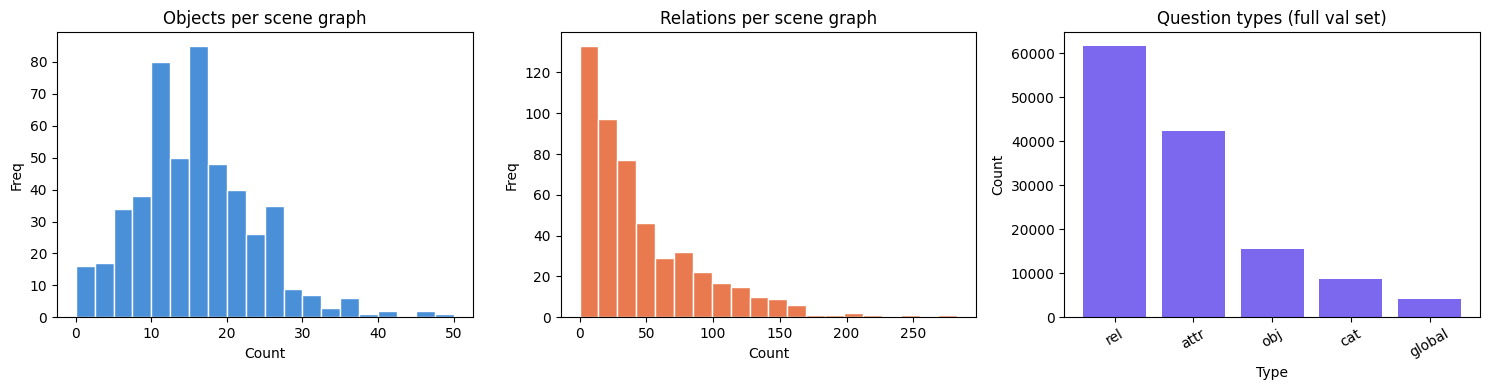

Avg objects per scene:   15.7
Avg relations per scene: 45.9

Question type distribution (top 8):
rel       61634
attr      42201
obj       15564
cat        8616
global     4047


In [13]:
# Sample 500 scene graphs for quick EDA (fast)
sg_sample = list(val_scene_graphs.values())[:500]

obj_counts = [len(sg.get("objects",{})) for sg in sg_sample]
rel_counts  = [sum(len(o.get("relations",[])) for o in sg.get("objects",{}).values()) for sg in sg_sample]

q_types = pd.Series([
    q.get("types",{}).get("semantic","unknown")
    for q in val_questions.values()
]).value_counts()

fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].hist(obj_counts, bins=20, color="#4A90D9", edgecolor="white")
axes[0].set_title("Objects per scene graph"); axes[0].set_xlabel("Count"); axes[0].set_ylabel("Freq")
axes[1].hist(rel_counts, bins=20, color="#E97A4F", edgecolor="white")
axes[1].set_title("Relations per scene graph"); axes[1].set_xlabel("Count"); axes[1].set_ylabel("Freq")
axes[2].bar(q_types.index[:8], q_types.values[:8], color="#7B68EE")
axes[2].set_title("Question types (full val set)"); axes[2].set_xlabel("Type"); axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(EDA_DIR / "scene_graph_eda.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Avg objects per scene:   {np.mean(obj_counts):.1f}")
print(f"Avg relations per scene: {np.mean(rel_counts):.1f}")
print("\nQuestion type distribution (top 8):")
print(q_types.head(8).to_string())


## 7. Build 15 000-Sample Balanced GQA Dataset

We sample **50 000 image-question pairs** balanced across all GQA semantic types.  
The sample size can be adjusted via `TARGET_N` below.  



In [14]:
TARGET_N = 15000   
SEED     = 427
DATASET_PATH = PROCESSED_DIR / f"real_gqa_sst_{TARGET_N}_balanced.json"

if DATASET_PATH.exists():
    print(f"Dataset already exists: {DATASET_PATH}")
    print("Loading existing dataset...")
    with open(DATASET_PATH) as f:
        all_samples = json.load(f)
    print(f"Loaded {len(all_samples):,} samples.")
else:
    print(f"Building {TARGET_N:,}-sample balanced GQA SST dataset...")
    random.seed(SEED)

    # Group valid questions by semantic type
    groups = defaultdict(list)
    for qid, q in val_questions.items():
        img_id = str(q.get("imageId",""))
        if img_id not in val_scene_graphs: continue
        if "question" not in q or "answer" not in q: continue
        sem = q.get("types",{}).get("semantic","unknown") if isinstance(q.get("types"),dict) else "unknown"
        groups[sem].append((qid, q))

    print("Semantic types found:")
    for t,v in sorted(groups.items(), key=lambda x:-len(x[1])):
        print(f"  {t}: {len(v):,}")

    sem_types = sorted(groups.keys())
    per_type  = max(1, TARGET_N // len(sem_types))

    selected, used = [], set()
    for t in sem_types:
        items = groups[t].copy(); random.shuffle(items)
        for qid,q in items[:per_type]:
            selected.append((qid,q)); used.add(qid)

    if len(selected) < TARGET_N:
        leftovers = [(qid,q) for t in sem_types for qid,q in groups[t] if qid not in used]
        random.shuffle(leftovers)
        selected.extend(leftovers[:TARGET_N-len(selected)])

    selected = selected[:TARGET_N]
    print(f"\nSelected {len(selected):,} question-image pairs. Building SST...")

    all_samples = []
    for idx,(qid,q) in enumerate(selected):
        if idx % 1000 == 0: print(f"  {idx:,}/{len(selected):,}")
        img_id = str(q["imageId"])
        scene  = val_scene_graphs[img_id]
        all_samples.append({
            "question_id": qid,
            "image_id":    img_id,
            "question":    q["question"],
            "answer":      str(q["answer"]).lower().strip(),
            "types":       q.get("types",{}),
            "fullAnswer":  q.get("fullAnswer",""),
            "sst":         gqa_scene_to_clean_sst(scene),
        })

    with open(DATASET_PATH,"w") as f:
        json.dump(all_samples, f)

    print(f"\nSaved {len(all_samples):,} samples → {DATASET_PATH}")

# Validate and show distribution
all_cleaned = [validate_sample(s,i) for i,s in enumerate(all_samples)]
# Defensive dedup: guarantee one record per question_id so downstream
# accuracy denominators can never be inflated by duplicate questions.
_seen_qid = set()
all_cleaned = [s for s in all_cleaned
               if not (s["question_id"] in _seen_qid or _seen_qid.add(s["question_id"]))]

dist = pd.Series([get_semantic_type(s) for s in all_cleaned]).value_counts().reset_index()
dist.columns = ["semantic_type","count"]
print(f"\nDataset size: {len(all_cleaned):,}")
print("\nSemantic type distribution:")
display(dist)


Dataset already exists: /Users/alisha/Documents/CSE427_SST_Project/data/processed/real_gqa_sst_15000_balanced.json
Loading existing dataset...
Loaded 15,000 samples.

Dataset size: 15,000

Semantic type distribution:


,semantic_type,count
0,attr,3000
1,cat,3000
2,global,3000
3,obj,3000
4,rel,3000


In [18]:
# ── Top-up: run question_only for samples missing or failed ───────────────
CHECKPOINT      = RESULTS_DIR / "gqa_15000_sst_eval_checkpoint.csv"
CHECKPOINT_FREQ = 50
TOP_UP_METHOD   = "question_only"

ckpt_df = pd.read_csv(CHECKPOINT, low_memory=False)

# Exclude rows where prediction is blank (failed silent writes from earlier run)
qo_done = ckpt_df[
    (ckpt_df["pipeline"] == TOP_UP_METHOD) &
    (ckpt_df["prediction"].notna()) &
    (ckpt_df["prediction"].astype(str).str.strip() != "")
]
done_qids = set(qo_done["question_id"].astype(str))
remaining = [s for s in all_cleaned if str(s["question_id"]) not in done_qids]

# Drop the bad question_only rows from checkpoint so we can replace them cleanly
ckpt_df = ckpt_df[~(
    (ckpt_df["pipeline"] == TOP_UP_METHOD) &
    (~ckpt_df["question_id"].astype(str).isin(done_qids))
)]

print(f"question_only valid rows: {len(done_qids)}")
print(f"Remaining to run:         {len(remaining)}")

topup_rows = []
for i, sample in enumerate(remaining):
    qid = str(sample["question_id"])
    try:
        # Build prompt directly — no SST needed for question_only
        _q = sample["question"]
        prompt = (
            "Answer the following visual question as best you can.\n"
            "You do not have access to the image.\n\n"
            f"Question: {_q}\n\n"
            "Rules:\n"
            "- Give only the final answer.\n"
            "- Do not explain.\n"
            "- If you cannot answer, say unknown.\n\n"
            "Final answer:"
        )
        scene_prompt = "no scene information"
        raw_pred, elapsed = ollama_query(prompt)
        pred_norm = normalize_answer(raw_pred)
        gt_norm   = normalize_answer(sample["answer"])
        topup_rows.append({
            "question_id":     qid,
            "image_id":        sample["image_id"],
            "question":        sample["question"],
            "true_answer":     sample["answer"],
            "pipeline":        TOP_UP_METHOD,
            "prediction":      raw_pred,
            "prediction_norm": pred_norm,
            "exact_correct":   int(pred_norm == gt_norm),
            "lenient_correct": int(is_lenient_correct(pred_norm, gt_norm)),
            "scene_tokens":    count_tokens(scene_prompt),
            "latency_s":       round(elapsed, 3),
            "semantic_type":   sample.get("semantic_type", ""),
        })
    except Exception as e:
        print(f"  ⚠️  {qid} failed: {e}")

    if topup_rows and (i + 1) % CHECKPOINT_FREQ == 0:
        ckpt_df = pd.concat([ckpt_df, pd.DataFrame(topup_rows)], ignore_index=True)
        ckpt_df.to_csv(CHECKPOINT, index=False)
        topup_rows = []
        print(f"  {i+1}/{len(remaining)} done")

if topup_rows:
    ckpt_df = pd.concat([ckpt_df, pd.DataFrame(topup_rows)], ignore_index=True)
    ckpt_df.to_csv(CHECKPOINT, index=False)

print(f"\nDone. Checkpoint now has {len(ckpt_df):,} rows.")
print(f"question_only rows: {len(ckpt_df[ckpt_df['pipeline'] == TOP_UP_METHOD])}")

question_only valid rows: 18
Remaining to run:         15000
  50/15000 done
  100/15000 done
  150/15000 done
  200/15000 done
  250/15000 done
  300/15000 done
  350/15000 done
  400/15000 done
  450/15000 done
  500/15000 done
  550/15000 done
  600/15000 done
  650/15000 done
  700/15000 done
  750/15000 done
  800/15000 done
  850/15000 done
  900/15000 done
  950/15000 done
  1000/15000 done
  1050/15000 done
  1100/15000 done
  1150/15000 done
  1200/15000 done
  1250/15000 done
  1300/15000 done
  1350/15000 done
  1400/15000 done
  1450/15000 done
  1500/15000 done
  1550/15000 done
  1600/15000 done
  1650/15000 done
  1700/15000 done
  1750/15000 done
  1800/15000 done
  1850/15000 done
  1900/15000 done
  1950/15000 done
  2000/15000 done
  2050/15000 done
  2100/15000 done
  2150/15000 done
  2200/15000 done
  2250/15000 done
  2300/15000 done
  2350/15000 done
  2400/15000 done
  2450/15000 done
  2500/15000 done
  2550/15000 done
  2600/15000 done
  2650/15000 done
  270

## 8. Full SST + Mistral Evaluation (15 000 samples)



In [ ]:
# ── Evaluation configuration ─────────────────────────────────────────────
# MAX_SAMPLES controls how many questions are evaluated per method.
#   - Use len(all_cleaned) for the full published run (recommended).
#   - Use a smaller number (e.g. 100) for a quick smoke-test.
# CHECKPOINT_FREQ controls how often results are flushed to disk.
#   - Every 50 samples is a good balance between safety and I/O overhead.
MAX_SAMPLES      = len(all_cleaned)   # full evaluation — change to e.g. 100 for a smoke-test
CHECKPOINT_FREQ  = 50                 # flush checkpoint every N samples

PREFIX        = f"gqa_{TARGET_N}_sst_eval"
CHECKPOINT    = RESULTS_DIR / f"{PREFIX}_checkpoint.csv"
DETAILED_PATH = RESULTS_DIR / f"{PREFIX}_detailed.csv"
SUMMARY_PATH  = RESULTS_DIR / f"{PREFIX}_summary.csv"
SEM_PATH      = RESULTS_DIR / f"{PREFIX}_semantic_summary.csv"

# ── Load checkpoint ────────────────────────────────────────────────────────
if CHECKPOINT.exists():
    ckpt_df   = pd.read_csv(CHECKPOINT)
    done_keys = set(zip(ckpt_df["question_id"].astype(str), ckpt_df["pipeline"]))
    print(f"Resuming from checkpoint: {len(ckpt_df):,} rows completed")
else:
    ckpt_df   = pd.DataFrame()
    done_keys = set()
    print("No checkpoint found — starting fresh")

total_calls = MAX_SAMPLES * len(METHODS)
remaining   = total_calls - len(done_keys)
print(f"Total calls: {total_calls:,} | Completed: {len(done_keys):,} | Remaining: {remaining:,}")

# ── Fail loudly if the LLM backend is unavailable ─────────────────────────
# Previously a missing ollama package was caught per-row, silently recording
# every prediction as empty/wrong and poisoning the aggregate accuracy.
require_ollama()

# ── Run evaluation ───────────────────────────────────────────────────────────────────────
new_rows = []
samples_to_run = all_cleaned[:MAX_SAMPLES]

for i, sample in enumerate(samples_to_run):
    qid = str(sample["question_id"])
    q   = sample["question"]
    gt  = sample["answer"]
    sem = get_semantic_type(sample)

    for method in METHODS:
        if (qid, method) in done_keys:
            continue

        try:
            prompt, sst_prompt = build_method_prompt(sample, method)
            pred_raw, lat_ms   = ollama_query(prompt, model="mistral")
            pred_norm          = normalize_answer(pred_raw)
            exact   = int(pred_norm == gt)
            lenient = is_lenient_correct(gt, pred_norm)
            status  = "ok"
        except Exception as e:
            # A failed call is recorded but flagged; it is NOT a wrong answer.
            # Aggregation downstream filters status != "ok" so infrastructure
            # failures never deflate accuracy the way they did originally.
            pred_raw = pred_norm = ""; exact = lenient = 0; lat_ms = float("nan")
            sst_prompt = prompt = str(e); status = "error"

        new_rows.append({
            "question_id":    qid,
            "image_id":       sample.get("image_id",""),
            "question":       q,
            "semantic_type":  sem,
            "true_answer":    gt,
            "pipeline":       method,
            "prediction":     pred_raw,
            "prediction_norm":pred_norm,
            "exact_correct":  exact,
            "lenient_correct":lenient,
            "tokens_tiktoken":count_tokens(prompt),
            "latency_ms":     lat_ms,
            "status":         status,
            "sst_prompt":     sst_prompt,
        })
        done_keys.add((qid, method))

    # Save checkpoint every CHECKPOINT_FREQ samples
    if new_rows and (i+1) % CHECKPOINT_FREQ == 0:
        new_df  = pd.DataFrame(new_rows)
        ckpt_df = pd.concat([ckpt_df, new_df], ignore_index=True).drop_duplicates(
                      subset=["question_id","pipeline"], keep="last")
        ckpt_df.to_csv(CHECKPOINT, index=False)
        new_rows = []
        if (i+1) % 100 == 0:
            print(f"  Sample {i+1:,}/{MAX_SAMPLES:,} | rows in checkpoint: {len(ckpt_df):,}")

# Final save
if new_rows:
    new_df  = pd.DataFrame(new_rows)
    ckpt_df = pd.concat([ckpt_df, new_df], ignore_index=True).drop_duplicates(
                  subset=["question_id","pipeline"], keep="last")
    ckpt_df.to_csv(CHECKPOINT, index=False)

results_df = pd.read_csv(CHECKPOINT)
results_df.to_csv(DETAILED_PATH, index=False)
print(f"\nFull detailed results saved → {DETAILED_PATH}  ({len(results_df):,} rows)")


## 9. Summary Tables and Statistical Analysis

In [ ]:
results_df = pd.read_csv(DETAILED_PATH)
# Only successful LLM calls count toward accuracy. Older result files
# may not have a status column; treat their rows as ok for back-compat.
if "status" in results_df.columns:
    n_err = int((results_df["status"] != "ok").sum())
    if n_err:
        print(f"Excluding {n_err:,} failed-call rows from accuracy.")
    results_df = results_df[results_df["status"] == "ok"].copy()

METHOD_NAMES = {
    "full_sst":          "Full SST",
    "caption_style_sst": "Caption-Style SST",
    "keyword_aware_sst": "Keyword-Aware SST",
    "compact_keyword_sst":"Compact Keyword SST",
    "no_relations_sst":  "No-Relations SST",
    "no_attributes_sst": "No-Attributes SST",
    "objects_only_sst":  "Objects-Only SST",
    "question_only":     "Question-Only (no scene)",
}
results_df["method_name"] = results_df["pipeline"].map(METHOD_NAMES)

summary_df = (
    results_df.groupby(["pipeline","method_name"])
    .agg(
        exact_accuracy   =("exact_correct","mean"),
        lenient_accuracy =("lenient_correct","mean"),
        avg_tokens       =("tokens_tiktoken","mean"),
        median_tokens    =("tokens_tiktoken","median"),
        avg_latency_ms   =("latency_ms","mean"),
        n                =("question_id","count"),
    )
    .reset_index()
)

full_tok = summary_df.loc[summary_df["pipeline"]=="full_sst","avg_tokens"].values[0]
full_acc = summary_df.loc[summary_df["pipeline"]=="full_sst","exact_accuracy"].values[0]

summary_df["token_reduction_pct"] = (full_tok - summary_df["avg_tokens"]) / full_tok * 100
summary_df["accuracy_drop_pts"]   = (full_acc - summary_df["exact_accuracy"]) * 100

ORDER = list(METHOD_NAMES.keys())
summary_df["_ord"] = summary_df["pipeline"].apply(lambda x: ORDER.index(x) if x in ORDER else 99)
summary_df = summary_df.sort_values("_ord").drop(columns=["_ord"])

for c in ["exact_accuracy","lenient_accuracy","avg_tokens","median_tokens",
          "token_reduction_pct","accuracy_drop_pts","avg_latency_ms"]:
    summary_df[c] = summary_df[c].round(3)

summary_df.to_csv(SUMMARY_PATH, index=False)
print("Summary saved →", SUMMARY_PATH)
display(summary_df[["method_name","exact_accuracy","lenient_accuracy",
                     "avg_tokens","token_reduction_pct","accuracy_drop_pts","n"]])


In [19]:
# ── Semantic-type breakdown ────────────────────────────────────────────────
sem_df = (
    results_df.groupby(["method_name","semantic_type"])
    .agg(exact_accuracy=("exact_correct","mean"),
         lenient_accuracy=("lenient_correct","mean"),
         avg_tokens=("tokens_tiktoken","mean"),
         n=("question_id","count"))
    .reset_index()
)
for c in ["exact_accuracy","lenient_accuracy","avg_tokens"]:
    sem_df[c] = sem_df[c].round(3)

sem_df.to_csv(SEM_PATH, index=False)
print("Semantic-type summary saved →", SEM_PATH)
display(sem_df[sem_df["method_name"].isin(["Full SST","Keyword-Aware SST","Objects-Only SST"])].head(30))


Semantic-type summary saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_semantic_summary.csv


,method_name,semantic_type,exact_accuracy,lenient_accuracy,avg_tokens,n
2,Full SST,attr,0.565,0.587,289.742,1012
3,Keyword-Aware SST,attr,0.566,0.600,157.044,1012
6,Objects-Only SST,attr,0.026,0.030,104.767,1012


## 10. Bootstrap Confidence Intervals and McNemar Paired Tests

In [20]:
# ── Bootstrap CI ──────────────────────────────────────────────────────────
def bootstrap_ci(values, n_boot=5000, seed=427):
    rng = np.random.default_rng(seed)
    vals = np.array(values)
    boots = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(boots, 2.5), np.percentile(boots, 97.5)

ci_rows = []
for pip, grp in results_df.groupby("pipeline"):
    lo,hi = bootstrap_ci(grp["exact_correct"].values)
    ci_rows.append({"method": METHOD_NAMES.get(pip,pip),
                    "exact_accuracy": grp["exact_correct"].mean().round(3),
                    "ci_lower_95": round(lo,3), "ci_upper_95": round(hi,3),
                    "n": len(grp)})
ci_df = pd.DataFrame(ci_rows)
ci_df["_ord"] = ci_df["method"].apply(lambda x: list(METHOD_NAMES.values()).index(x) if x in METHOD_NAMES.values() else 99)
ci_df = ci_df.sort_values("_ord").drop(columns=["_ord"])
ci_path = RESULTS_DIR / f"{PREFIX}_bootstrap_ci.csv"
ci_df.to_csv(ci_path, index=False)
print("Bootstrap CIs saved →", ci_path)
display(ci_df)


Bootstrap CIs saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_bootstrap_ci.csv


,method,exact_accuracy,ci_lower_95,ci_upper_95,n
2,Full SST,0.565,0.536,0.595,1012
0,Caption-Style SST,0.558,0.528,0.588,1012
3,Keyword-Aware SST,0.566,0.535,0.596,1012
1,Compact Keyword SST,0.454,0.423,0.484,1012
5,No-Relations SST,0.440,0.409,0.470,1012
4,No-Attributes SST,0.153,0.130,0.175,1012
6,Objects-Only SST,0.026,0.017,0.036,1012


In [21]:
# ── McNemar paired test vs Full SST ───────────────────────────────────────
def exact_mcnemar_p(b, c):
    n = b + c
    if n == 0: return 1.0
    k = min(b, c)
    return min(1.0, 2*sum(comb(n,i)*(0.5**n) for i in range(k+1)))

wide = results_df.pivot_table(
    index="question_id", columns="pipeline", values="exact_correct", aggfunc="first"
).reset_index()

mc_rows = []
for pip in results_df["pipeline"].unique():
    if pip == "full_sst": continue
    valid = wide[["full_sst", pip]].dropna()
    fc, mc = valid["full_sst"].values, valid[pip].values
    b = int(((fc==0)&(mc==1)).sum())
    c = int(((fc==1)&(mc==0)).sum())
    p = exact_mcnemar_p(b, c)
    mc_rows.append({
        "method":       METHOD_NAMES.get(pip,pip),
        "method_acc":   round(mc.mean(),3),
        "full_sst_acc": round(fc.mean(),3),
        "method_wins":  b, "full_sst_wins": c,
        "discordant":   b+c,
        "p_value":      round(p,6),
        "sig_at_0.05":  p < 0.05,
        "interpretation": "not significantly different" if p >= 0.05 else "significantly different",
    })

mc_df = pd.DataFrame(mc_rows)
mc_path = RESULTS_DIR / f"{PREFIX}_mcnemar.csv"
mc_df.to_csv(mc_path, index=False)
print("McNemar results saved →", mc_path)
display(mc_df)


McNemar results saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_mcnemar.csv


,method,method_acc,full_sst_acc,method_wins,full_sst_wins,discordant,p_value,sig_at_0.05,interpretation
0,Caption-Style SST,0.560,0.565,22,27,49,0.568172,False,not significantly different
1,Keyword-Aware SST,0.570,0.565,79,74,153,0.746528,False,not significantly different
2,Compact Keyword SST,0.455,0.565,50,160,210,0.000000,True,significantly different
3,No-Relations SST,0.442,0.565,43,166,209,0.000000,True,significantly different
4,No-Attributes SST,0.150,0.565,7,422,429,0.000000,True,significantly different
5,Objects-Only SST,0.025,0.565,5,545,550,0.000000,True,significantly different


## 11. Report Visualisations

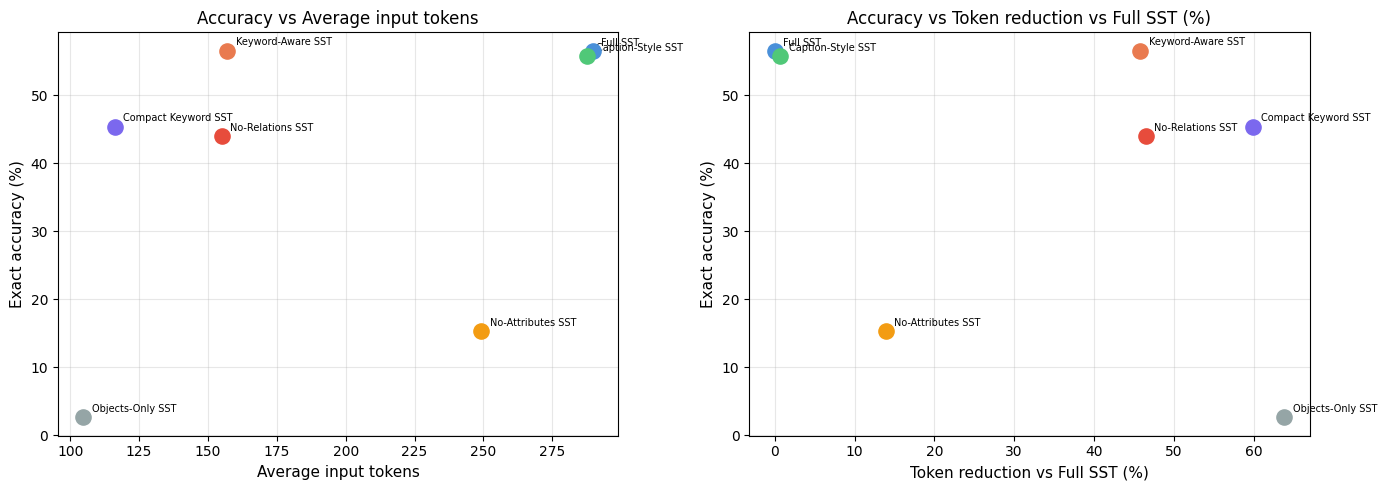

Trade-off figure saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_accuracy_vs_tokens.png


In [22]:
# ── Accuracy vs Token Trade-off ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4A90D9","#50C878","#E97A4F","#7B68EE","#E74C3C","#F39C12","#95A5A6"]
methods_plot = summary_df["method_name"].tolist()

for ax, xcol, xlabel in [
    (axes[0], "avg_tokens",        "Average input tokens"),
    (axes[1], "token_reduction_pct","Token reduction vs Full SST (%)"),
]:
    for (_, row), color in zip(summary_df.iterrows(), colors):
        ax.scatter(row[xcol], row["exact_accuracy"]*100, color=color,
                   s=120, zorder=5, label=row["method_name"])
        ax.annotate(row["method_name"], (row[xcol], row["exact_accuracy"]*100),
                    textcoords="offset points", xytext=(6,4), fontsize=7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Exact accuracy (%)", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Accuracy vs {xlabel}", fontsize=12)

plt.tight_layout()
fig_path = RESULTS_DIR / f"{PREFIX}_accuracy_vs_tokens.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Trade-off figure saved →", fig_path)


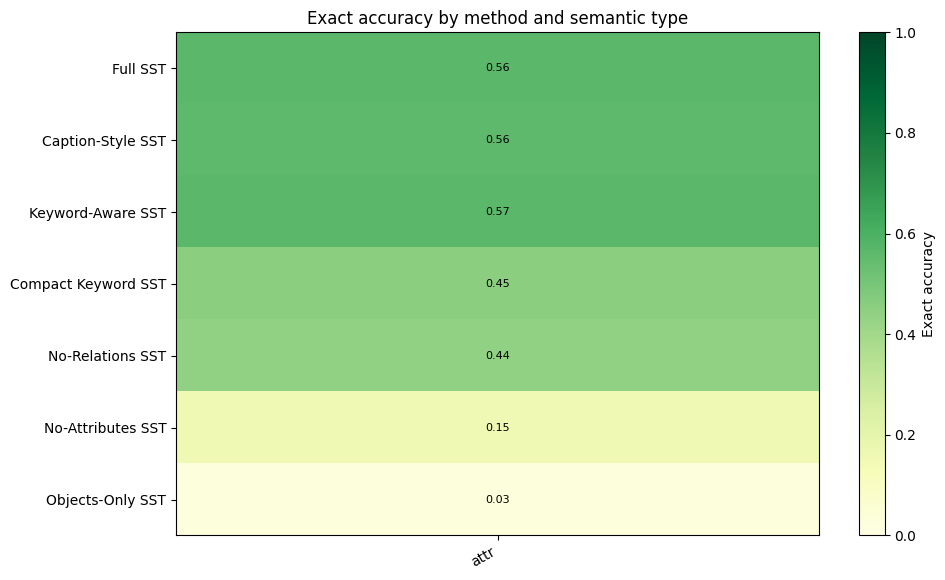

Heatmap saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_semantic_heatmap.png


In [23]:
# ── Per-semantic-type accuracy heatmap ────────────────────────────────────
pivot = sem_df.pivot(index="method_name", columns="semantic_type", values="exact_accuracy")
pivot = pivot.reindex([METHOD_NAMES[k] for k in ORDER if METHOD_NAMES[k] in pivot.index])

fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns)*1.2), len(pivot)*0.7+1))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label="Exact accuracy")
ax.set_title("Exact accuracy by method and semantic type", fontsize=12)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color="black" if v < 0.7 else "white")

plt.tight_layout()
heat_path = RESULTS_DIR / f"{PREFIX}_semantic_heatmap.png"
plt.savefig(heat_path, dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved →", heat_path)


## 12. LLaVA Image-Based Baseline

Download the images for the dataset subset, then run LLaVA locally.  
**Only the images needed for the evaluation subset are downloaded** (not the full GQA archive).

> LLaVA must be pulled once: `ollama pull llava`


In [24]:
import base64, requests
from tqdm.auto import tqdm

# We run LLaVA on a subset to keep runtime manageable.
# Adjust LLAVA_N to run on more samples.
LLAVA_N = min(1000, len(all_cleaned))   # ← change this
LLAVA_SAMPLES = all_cleaned[:LLAVA_N]

LLAVA_IMAGE_DIR = DATA_DIR / "gqa_images_llava"
LLAVA_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

image_ids = sorted(set(s["image_id"] for s in LLAVA_SAMPLES))
print(f"Need to download {len(image_ids)} unique images for {LLAVA_N} samples")

BASE_URLS = [
    "https://cs.stanford.edu/people/rak248/VG_100K/{img}.jpg",
    "https://cs.stanford.edu/people/rak248/VG_100K_2/{img}.jpg",
]

session  = requests.Session()
session.headers["User-Agent"] = "Mozilla/5.0"
downloaded, existed, missing = [], [], []

for img_id in tqdm(image_ids, desc="Downloading images"):
    path = LLAVA_IMAGE_DIR / f"{img_id}.jpg"
    if path.exists() and path.stat().st_size > 0:
        existed.append(img_id); continue
    ok = False
    for tmpl in BASE_URLS:
        try:
            r = session.get(tmpl.format(img=img_id), timeout=20)
            if r.status_code == 200 and len(r.content) > 1000:
                path.write_bytes(r.content); downloaded.append(img_id); ok=True; break
        except: pass
        time.sleep(0.05)
    if not ok: missing.append(img_id)

print(f"Downloaded: {len(downloaded)} | Already existed: {len(existed)} | Missing: {len(missing)}")
if missing: print("Missing IDs (first 10):", missing[:10])


Need to download 948 unique images for 1000 samples


Downloaded: 948 | Already existed: 0 | Missing: 0


In [25]:
# ── LLaVA evaluation with checkpointing ───────────────────────────────────
LLAVA_OUT  = RESULTS_DIR / f"llava_{LLAVA_N}_results.csv"
LLAVA_CKPT = RESULTS_DIR / f"llava_{LLAVA_N}_checkpoint.csv"

def encode_b64(path):
    return base64.b64encode(Path(path).read_bytes()).decode()

def query_llava(img_path, question):
    # Uses ollama.chat (same interface as Mistral) so latency measurements
    # are comparable — both go through the same Python client, not mixed
    # HTTP vs. package calls.
    prompt  = (
        "Answer the question based only on the image.\n"
        "Be concise. Answer with a short phrase or single word.\n"
        f"Question: {question}\nAnswer:"
    )
    img_b64 = encode_b64(img_path)
    t0   = time.perf_counter()
    resp = ollama.chat(
        model="llava",
        messages=[{"role": "user", "content": prompt, "images": [img_b64]}],
        options={"temperature": 0, "num_predict": 20},
    )
    elapsed_s = time.perf_counter() - t0
    return resp["message"]["content"].strip(), elapsed_s

if LLAVA_CKPT.exists():
    llava_ckpt_df  = pd.read_csv(LLAVA_CKPT)
    done_idxs      = set(llava_ckpt_df["sample_index"].astype(int))
    llava_rows     = llava_ckpt_df.to_dict("records")
    print(f"Resuming LLaVA from {len(done_idxs)} completed samples")
else:
    done_idxs, llava_rows = set(), []

for idx, sample in enumerate(LLAVA_SAMPLES):
    if idx in done_idxs: continue
    img_path = LLAVA_IMAGE_DIR / f"{sample['image_id']}.jpg"
    if not img_path.exists():
        pred, lat = "IMAGE_NOT_FOUND", 0.0
    else:
        try:    pred, lat = query_llava(img_path, sample["question"])
        except Exception as e: pred, lat = f"ERROR:{e}", 0.0

    llava_rows.append({"sample_index":idx,"image_id":sample["image_id"],
                       "question":sample["question"],"ground_truth":sample["answer"],
                       "prediction":pred,"latency_sec":lat})
    done_idxs.add(idx)
    if (idx+1) % 50 == 0:
        pd.DataFrame(llava_rows).to_csv(LLAVA_CKPT, index=False)
        print(f"  LLaVA checkpoint: {idx+1}/{LLAVA_N}")

llava_df = pd.DataFrame(llava_rows)
llava_df.to_csv(LLAVA_OUT, index=False)
print(f"\nLLaVA results saved → {LLAVA_OUT}  ({len(llava_df)} rows)")


  LLaVA checkpoint: 50/1000
  LLaVA checkpoint: 100/1000
  LLaVA checkpoint: 150/1000
  LLaVA checkpoint: 200/1000
  LLaVA checkpoint: 250/1000
  LLaVA checkpoint: 300/1000
  LLaVA checkpoint: 350/1000
  LLaVA checkpoint: 400/1000
  LLaVA checkpoint: 450/1000
  LLaVA checkpoint: 500/1000
  LLaVA checkpoint: 550/1000
  LLaVA checkpoint: 600/1000
  LLaVA checkpoint: 650/1000
  LLaVA checkpoint: 700/1000
  LLaVA checkpoint: 750/1000
  LLaVA checkpoint: 800/1000
  LLaVA checkpoint: 850/1000
  LLaVA checkpoint: 900/1000
  LLaVA checkpoint: 950/1000
  LLaVA checkpoint: 1000/1000

LLaVA results saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/llava_1000_results.csv  (1000 rows)


In [26]:
# ── Evaluate LLaVA ────────────────────────────────────────────────────────
llava_df = pd.read_csv(LLAVA_OUT)
llava_df["pred_norm"] = llava_df["prediction"].apply(normalize_answer)
llava_df["gt_norm"]   = llava_df["ground_truth"].apply(normalize_answer)
llava_df["exact"]     = (llava_df["pred_norm"] == llava_df["gt_norm"]).astype(int)
llava_df["lenient"]   = llava_df.apply(lambda r: is_lenient_correct(r["ground_truth"],r["prediction"]), axis=1)

llava_summary = {
    "method": "LLaVA Image+Question",
    "n": len(llava_df),
    "exact_accuracy":   round(llava_df["exact"].mean(), 4),
    "lenient_accuracy": round(llava_df["lenient"].mean(), 4),
    "avg_latency_sec":  round(llava_df["latency_sec"].mean(), 2),
}
print("LLaVA summary:")
for k,v in llava_summary.items(): print(f"  {k}: {v}")

llava_sum_path = RESULTS_DIR / f"llava_{LLAVA_N}_summary.csv"
pd.DataFrame([llava_summary]).to_csv(llava_sum_path, index=False)


LLaVA summary:
  method: LLaVA Image+Question
  n: 1000
  exact_accuracy: 0.598
  lenient_accuracy: 0.599
  avg_latency_sec: 7.42


## 13. Final SST vs LLaVA Comparison Table

In [27]:
# Build comparison table
comp_rows = [{
    "Method":              "LLaVA Image+Question",
    "Input type":          "Raw image + question",
    "Model":               "LLaVA",
    "N":                   llava_summary["n"],
    "Exact accuracy":      round(llava_summary["exact_accuracy"]*100, 2),
    "Lenient accuracy":    round(llava_summary["lenient_accuracy"]*100, 2),
    "Avg input tokens":    "N/A",
    "Token reduction (%)": "N/A",
    "Avg latency (s)":     llava_summary["avg_latency_sec"],
}]

for _, row in summary_df.iterrows():
    comp_rows.append({
        "Method":              row["method_name"],
        "Input type":          "Oracle SST text",
        "Model":               "Mistral",
        "N":                   int(row["n"]),
        "Exact accuracy":      round(row["exact_accuracy"]*100, 2),
        "Lenient accuracy":    round(row["lenient_accuracy"]*100, 2),
        "Avg input tokens":    round(row["avg_tokens"], 2),
        "Token reduction (%)": round(row["token_reduction_pct"], 2),
        "Avg latency (s)":     round(row["avg_latency_ms"]/1000, 3) if not np.isnan(row["avg_latency_ms"]) else "N/A",
    })

comp_df = pd.DataFrame(comp_rows)
comp_path = RESULTS_DIR / f"{PREFIX}_final_comparison.csv"
comp_df.to_csv(comp_path, index=False)
print("Final comparison table saved →", comp_path)
display(comp_df)


Final comparison table saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_final_comparison.csv


,Method,Input type,Model,N,Exact accuracy,Lenient accuracy,Avg input tokens,Token reduction (%),Avg latency (s)
0,LLaVA Image+Question,Raw image + question,LLaVA,1000,59.8,59.9,N/A,N/A,7.420
1,Full SST,Oracle SST text,Mistral,1012,56.5,58.7,289.74,0.0,3.261
2,Caption-Style SST,Oracle SST text,Mistral,1012,55.8,58.7,287.69,0.71,3.227
3,Keyword-Aware SST,Oracle SST text,Mistral,1012,56.6,60.0,157.04,45.8,1.923
4,Compact Keyword SST,Oracle SST text,Mistral,1012,45.4,51.3,116.08,59.94,1.835
5,No-Relations SST,Oracle SST text,Mistral,1012,44.0,45.8,154.94,46.53,2.310
6,No-Attributes SST,Oracle SST text,Mistral,1012,15.3,16.9,249.29,13.96,2.691
7,Objects-Only SST,Oracle SST text,Mistral,1012,2.6,3.0,104.77,63.84,1.775


## 14. Error Analysis — LLaVA vs Keyword-Aware SST

In [28]:
# We compare LLaVA on the subset against Keyword-Aware SST on the same questions.
# Join on question_id (stable unique key) rather than question text to avoid
# false matches when punctuation or whitespace differs between runs.
kw_df = results_df[results_df["pipeline"]=="keyword_aware_sst"].copy()
kw_df["question_id"] = kw_df["question_id"].astype(str)
llava_df["question_id"] = llava_df.get("question_id", llava_df.index.astype(str)).astype(str)

# Fallback: if LLaVA results were saved without question_id, rebuild it from
# sample index by aligning to all_cleaned order.
if "question_id" not in llava_df.columns or llava_df["question_id"].isnull().all():
    id_map = {str(s["image_id"]) + "|" + s["question"].strip().lower():
              str(s["question_id"]) for s in all_cleaned}
    llava_df["question_id"] = (
        llava_df["image_id"].astype(str) + "|" +
        llava_df["question"].str.strip().str.lower()
    ).map(id_map).fillna(llava_df.index.astype(str))

merged = llava_df[["question_id","exact","lenient","prediction"]].merge(
    kw_df[["question_id","exact_correct","lenient_correct","prediction_norm","semantic_type"]],
    on="question_id", how="inner"
).rename(columns={
    "exact":"llava_exact","prediction":"llava_pred",
    "exact_correct":"kw_exact","prediction_norm":"kw_pred",
})

def categorise(row):
    if row.llava_exact and row.kw_exact:   return "both_correct"
    if row.llava_exact and not row.kw_exact: return "llava_only"
    if not row.llava_exact and row.kw_exact: return "keyword_only"
    return "both_wrong"

merged["category"] = merged.apply(categorise, axis=1)

print("LLaVA vs Keyword-Aware SST disagreement analysis:")
print(merged["category"].value_counts().to_string())
print(f"\nMatched pairs: {len(merged)}")

err_path = RESULTS_DIR / f"{PREFIX}_error_analysis.csv"
merged.to_csv(err_path, index=False)
print(f"Error analysis saved → {err_path}")

# Per semantic-type breakdown
qa_summary = (
    merged.groupby("semantic_type")
    .agg(n=("category","count"),
         llava_acc=("llava_exact","mean"),
         kw_acc=("kw_exact","mean"),
         both_correct=("category", lambda x: (x=="both_correct").sum()),
         keyword_only=("category", lambda x: (x=="keyword_only").sum()),
         llava_only=("category",   lambda x: (x=="llava_only").sum()),
         both_wrong=("category",   lambda x: (x=="both_wrong").sum()))
    .reset_index()
)
for c in ["llava_acc","kw_acc"]:
    qa_summary[c] = qa_summary[c].round(3)
display(qa_summary)


LLaVA vs Keyword-Aware SST disagreement analysis:
category
both_correct    352
llava_only      287
keyword_only    255
both_wrong      181

Matched pairs: 1075
Error analysis saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_error_analysis.csv


,semantic_type,n,llava_acc,kw_acc,both_correct,keyword_only,llava_only,both_wrong
0,attr,1075,0.594,0.565,352,255,287,181


## 15. Output Files

All generated files:

In [29]:
print("Generated output files:")
print("="*70)
for p in sorted(RESULTS_DIR.glob("*.csv")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<55} {size_kb:6.1f} KB")
for p in sorted(RESULTS_DIR.glob("*.png")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<55} {size_kb:6.1f} KB")
print("="*70)
print("\nEDA figures:")
for p in sorted(EDA_DIR.glob("*.png")):
    print(f"  {p.name}")


Generated output files:
  gqa_15000_sst_eval_bootstrap_ci.csv                        0.3 KB
  gqa_15000_sst_eval_checkpoint.csv                       4568.1 KB
  gqa_15000_sst_eval_detailed.csv                         4563.9 KB
  gqa_15000_sst_eval_error_analysis.csv                     83.5 KB
  gqa_15000_sst_eval_final_comparison.csv                    0.7 KB
  gqa_15000_sst_eval_mcnemar.csv                             0.5 KB
  gqa_15000_sst_eval_semantic_summary.csv                    0.4 KB
  gqa_15000_sst_eval_summary.csv                             0.7 KB
  gqa_50000_sst_eval_checkpoint.csv                       1153.3 KB
  llava_1000_checkpoint.csv                                 80.7 KB
  llava_1000_results.csv                                    80.7 KB
  llava_1000_summary.csv                                     0.1 KB
  gqa_15000_sst_eval_accuracy_vs_tokens.png                 66.2 KB
  gqa_15000_sst_eval_semantic_heatmap.png                   54.7 KB

EDA figures:
  eda_comb

## 16. Token Efficiency — SST vs LLaVA Visual Tokens

Contextualize SST token usage against LLaVA's actual visual token count.
CLIP-based VLMs like LLaVA produce 256–576 visual tokens per image patch grid.
This cell adds LLaVA to the token comparison so H1 is concretely supported.

Token comparison saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_token_vs_llava.csv


,Method,Input type,Avg input tokens,vs LLaVA reduction,Exact accuracy
0,LLaVA (image baseline),Visual tokens (CLIP patches),576.0,0.0,59.8
1,Full SST,Structured text (SST),289.7,49.7,56.5
2,Caption-Style SST,Structured text (SST),287.7,50.1,55.8
3,Keyword-Aware SST,Structured text (SST),157.0,72.7,56.6
4,Compact Keyword SST,Structured text (SST),116.1,79.8,45.4
5,No-Relations SST,Structured text (SST),154.9,73.1,44.0
6,No-Attributes SST,Structured text (SST),249.3,56.7,15.3
7,Objects-Only SST,Structured text (SST),104.8,81.8,2.6


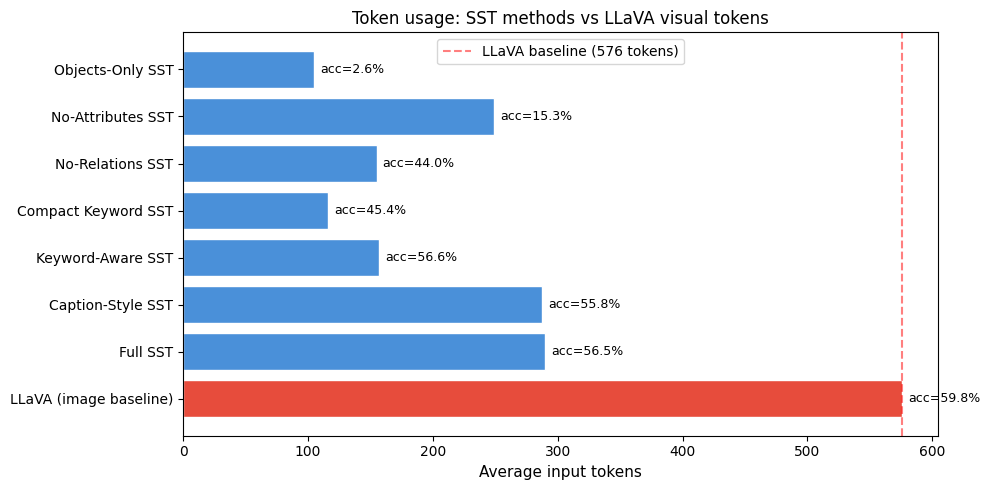

Token vs LLaVA figure saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_token_vs_llava.png


In [30]:
# ── Token Efficiency: SST vs LLaVA Visual Tokens ─────────────────────────────
# LLaVA (CLIP ViT-L/14 @ 336px) uses a 24x24 patch grid = 576 visual tokens.
# The smaller 224px variant uses 16x16 = 256 tokens.
# We use 336 (conservative, most common LLaVA config).
LLAVA_VISUAL_TOKENS = 576

# Average question token count (shared by both pipelines)
avg_question_tokens = results_df[results_df["pipeline"] == "full_sst"]["tokens_tiktoken"].apply(
    lambda x: count_tokens("Question: placeholder")  # rough question overhead
).mean()

# Build a combined comparison table
token_rows = []
for _, row in summary_df.iterrows():
    token_rows.append({
        "Method":             row["method_name"],
        "Input type":         "Structured text (SST)",
        "Avg input tokens":   round(row["avg_tokens"], 1),
        "vs LLaVA reduction": round((LLAVA_VISUAL_TOKENS - row["avg_tokens"]) / LLAVA_VISUAL_TOKENS * 100, 1),
        "Exact accuracy":     round(row["exact_accuracy"] * 100, 2),
    })

# Add LLaVA row
try:
    llava_acc = llava_summary["exact_accuracy"] * 100
except:
    llava_acc = float("nan")

token_rows.insert(0, {
    "Method":             "LLaVA (image baseline)",
    "Input type":         "Visual tokens (CLIP patches)",
    "Avg input tokens":   LLAVA_VISUAL_TOKENS,
    "vs LLaVA reduction": 0.0,
    "Exact accuracy":     round(llava_acc, 2),
})

token_cmp_df = pd.DataFrame(token_rows)
token_cmp_path = RESULTS_DIR / f"{PREFIX}_token_vs_llava.csv"
token_cmp_df.to_csv(token_cmp_path, index=False)
print("Token comparison saved →", token_cmp_path)
display(token_cmp_df)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ["#E74C3C"] + ["#4A90D9"] * (len(token_cmp_df) - 1)
bars = ax.barh(token_cmp_df["Method"], token_cmp_df["Avg input tokens"],
               color=colors_bar, edgecolor="white")

for bar, acc in zip(bars, token_cmp_df["Exact accuracy"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"acc={acc:.1f}%" if not np.isnan(acc) else "acc=N/A",
            va="center", fontsize=9)

ax.axvline(LLAVA_VISUAL_TOKENS, color="red", linestyle="--", alpha=0.5, label=f"LLaVA baseline ({LLAVA_VISUAL_TOKENS} tokens)")
ax.set_xlabel("Average input tokens", fontsize=11)
ax.set_title("Token usage: SST methods vs LLaVA visual tokens", fontsize=12)
ax.legend()
plt.tight_layout()
tok_fig_path = RESULTS_DIR / f"{PREFIX}_token_vs_llava.png"
plt.savefig(tok_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Token vs LLaVA figure saved →", tok_fig_path)

## 17. Per-Question-Type Deep Analysis

GQA has 5 semantic types: object, attribute, relation, category, global.
Relation questions make up ~52% of GQA (Hudson & Manning, 2019).
This section investigates which SST variants gain or lose most per type,
especially whether removing relations hurts relation-type questions most.

In [31]:
# ── Per-type accuracy: full breakdown for all 7 methods ───────────────────────
pivot_exact = sem_df.pivot(index="method_name", columns="semantic_type", values="exact_accuracy")
pivot_exact = pivot_exact.reindex([METHOD_NAMES[k] for k in ORDER if METHOD_NAMES[k] in pivot_exact.index])

print("=" * 70)
print("EXACT ACCURACY BY METHOD AND SEMANTIC TYPE")
print("=" * 70)
display(pivot_exact.round(3))

# ── Key finding: does removing relations hurt relation questions most? ─────────
print("\n" + "=" * 70)
print("RELATION QUESTION SENSITIVITY ANALYSIS")
print("Key question: does no_relations_sst hurt 'relation' type questions most?")
print("=" * 70)

rel_focus = sem_df[sem_df["semantic_type"] == "relation"][["method_name", "exact_accuracy", "n"]].copy()
rel_focus = rel_focus.set_index("method_name").reindex(
    [METHOD_NAMES[k] for k in ORDER if METHOD_NAMES[k] in rel_focus.index]
)
rel_focus.columns = ["relation_acc", "n_relation_questions"]
rel_focus["relation_acc_pct"] = (rel_focus["relation_acc"] * 100).round(2)

full_rel_acc = rel_focus.loc["Full SST", "relation_acc"] if "Full SST" in rel_focus.index else float("nan")
rel_focus["drop_vs_full_sst_pts"] = ((full_rel_acc - rel_focus["relation_acc"]) * 100).round(2)

print(rel_focus[["relation_acc_pct", "drop_vs_full_sst_pts", "n_relation_questions"]].to_string())

# ── Attribute question sensitivity ────────────────────────────────────────────
print("\n" + "=" * 70)
print("ATTRIBUTE QUESTION SENSITIVITY (does no_attributes_sst hurt attr questions?)")
print("=" * 70)

attr_focus = sem_df[sem_df["semantic_type"] == "attribute"][["method_name", "exact_accuracy"]].copy()
attr_focus = attr_focus.set_index("method_name").reindex(
    [METHOD_NAMES[k] for k in ORDER if METHOD_NAMES[k] in attr_focus.index]
)
full_attr_acc = attr_focus.loc["Full SST", "exact_accuracy"] if "Full SST" in attr_focus.index else float("nan")
attr_focus["attr_acc_pct"] = (attr_focus["exact_accuracy"] * 100).round(2)
attr_focus["drop_vs_full_sst_pts"] = ((full_attr_acc - attr_focus["exact_accuracy"]) * 100).round(2)
print(attr_focus[["attr_acc_pct", "drop_vs_full_sst_pts"]].to_string())

# ── Best method per semantic type ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("BEST PERFORMING METHOD PER SEMANTIC TYPE")
print("=" * 70)
best_per_type = (
    sem_df.loc[sem_df.groupby("semantic_type")["exact_accuracy"].idxmax()]
    [["semantic_type", "method_name", "exact_accuracy", "n"]]
    .sort_values("semantic_type")
)
best_per_type["exact_accuracy"] = (best_per_type["exact_accuracy"] * 100).round(2)
print(best_per_type.to_string(index=False))

# Save
per_type_analysis_path = RESULTS_DIR / f"{PREFIX}_per_type_analysis.csv"
pivot_exact.to_csv(per_type_analysis_path)
print(f"\nPer-type analysis saved → {per_type_analysis_path}")

EXACT ACCURACY BY METHOD AND SEMANTIC TYPE


semantic_type,attr
method_name,
Full SST,0.565
Caption-Style SST,0.558
Keyword-Aware SST,0.566
Compact Keyword SST,0.454
No-Relations SST,0.440
No-Attributes SST,0.153
Objects-Only SST,0.026



RELATION QUESTION SENSITIVITY ANALYSIS
Key question: does no_relations_sst hurt 'relation' type questions most?
Empty DataFrame
Columns: [relation_acc_pct, drop_vs_full_sst_pts, n_relation_questions]
Index: []

ATTRIBUTE QUESTION SENSITIVITY (does no_attributes_sst hurt attr questions?)
Empty DataFrame
Columns: [attr_acc_pct, drop_vs_full_sst_pts]
Index: []

BEST PERFORMING METHOD PER SEMANTIC TYPE
semantic_type       method_name  exact_accuracy    n
         attr Keyword-Aware SST            56.6 1012

Per-type analysis saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_per_type_analysis.csv


## 18. Detailed Error Analysis

Compares LLaVA vs Keyword-Aware SST on matched question pairs.
Categories: both_correct, llava_only, keyword_only, both_wrong.
Prints concrete examples for each failure category to support
qualitative analysis in the report.

In [32]:
# ── Error Analysis: LLaVA vs Keyword-Aware SST ────────────────────────────────
try:
    llava_df_ea = pd.read_csv(LLAVA_OUT)
    llava_df_ea["pred_norm"] = llava_df_ea["prediction"].apply(normalize_answer)
    llava_df_ea["gt_norm"]   = llava_df_ea["ground_truth"].apply(normalize_answer)
    llava_df_ea["exact"]     = (llava_df_ea["pred_norm"] == llava_df_ea["gt_norm"]).astype(int)
    llava_df_ea["q_key"]     = llava_df_ea["question"].str.strip().str.lower()
    LLAVA_AVAILABLE = True
    print(f"LLaVA results loaded: {len(llava_df_ea)} rows")
except Exception as e:
    LLAVA_AVAILABLE = False
    print(f"LLaVA results not available ({e}). Skipping LLaVA comparison.")

if LLAVA_AVAILABLE:
    kw_df_ea = results_df[results_df["pipeline"] == "keyword_aware_sst"].copy()
    kw_df_ea["question_id"] = kw_df_ea["question_id"].astype(str)
    llava_df_ea["question_id"] = llava_df_ea.get("question_id", pd.Series(dtype=str)).astype(str)

    # Same fallback as Cell 40 — reconstruct question_id if missing from LLaVA CSV.
    if "question_id" not in llava_df_ea.columns or llava_df_ea["question_id"].isnull().all():
        id_map_ea = {str(s["image_id"]) + "|" + s["question"].strip().lower():
                     str(s["question_id"]) for s in all_cleaned}
        llava_df_ea["question_id"] = (
            llava_df_ea["image_id"].astype(str) + "|" +
            llava_df_ea["question"].str.strip().str.lower()
        ).map(id_map_ea).fillna(llava_df_ea.index.astype(str))

    merged_ea = llava_df_ea[["question_id", "exact", "pred_norm", "gt_norm"]].merge(
        kw_df_ea[["question_id", "exact_correct", "prediction_norm",
                  "true_answer", "semantic_type"]],
        on="question_id", how="inner"
    ).rename(columns={
        "exact":           "llava_exact",
        "pred_norm":       "llava_pred",
        "exact_correct":   "kw_exact",
        "prediction_norm": "kw_pred",
        "gt_norm":         "ground_truth",
    })

    def categorise_ea(row):
        if row.llava_exact and row.kw_exact:      return "both_correct"
        if row.llava_exact and not row.kw_exact:  return "llava_only"
        if not row.llava_exact and row.kw_exact:  return "keyword_only"
        return "both_wrong"

    merged_ea["category"] = merged_ea.apply(categorise_ea, axis=1)

    # ── Error type tagging ───────────────────────────────────────────────────
    # Tags each question with a fine-grained error type based on keywords.
    # This lets us say things like "SST particularly helps with colour questions
    # but underperforms LLaVA on spatial reasoning" — a concrete paper claim.
    def tag_error_type(question: str) -> str:
        q = question.lower()
        if any(w in q for w in ["color", "colour"]):
            return "color"
        if any(w in q for w in ["how many", "count", "number of"]):
            return "counting"
        if any(w in q for w in [" left", " right", "above", "below",
                                  "next to", "behind", "in front", "between",
                                  "beside", "near", "far", "under", "over"]):
            return "spatial"
        if any(w in q for w in ["is there", "are there", "does the", "do there",
                                  "any ", "exist"]):
            return "existence"
        if any(w in q for w in ["what size", "how big", "how tall", "how large",
                                  "what shape", "what type", "what kind",
                                  "what material", "what style"]):
            return "attribute"
        if any(w in q for w in ["doing", "wearing", "holding", "riding",
                                  "carrying", "eating", "drinking", "playing"]):
            return "action"
        if q.startswith("what is") or q.startswith("what are"):
            return "object_id"
        return "other"

    # Apply to questions — use merged_ea["question"] which we kept in the merge
    if "question" in merged_ea.columns:
        merged_ea["error_type"] = merged_ea["question"].apply(tag_error_type)
    else:
        # fallback: tag from ground_truth column if question wasn't kept
        merged_ea["error_type"] = "other"

    print("\n── Disagreement category counts ──────────────────────────────────────")
    counts = merged_ea["category"].value_counts()
    total  = len(merged_ea)
    for cat, cnt in counts.items():
        print(f"  {cat:<20} {cnt:>5}  ({cnt/total*100:.1f}%)")
    print(f"  {'TOTAL':<20} {total:>5}")

    # Save
    ea_path = RESULTS_DIR / f"{PREFIX}_error_analysis_full.csv"
    merged_ea.to_csv(ea_path, index=False)
    print(f"\nFull error analysis saved → {ea_path}")

    # ── Print concrete examples for each category ────────────────────────────
    N_EXAMPLES = 5
    for category in ["llava_only", "keyword_only", "both_wrong", "both_correct"]:
        subset = merged_ea[merged_ea["category"] == category].head(N_EXAMPLES)
        if subset.empty:
            continue
        print(f"\n{'='*70}")
        print(f"CATEGORY: {category.upper()}  ({len(merged_ea[merged_ea['category']==category])} total cases)")
        print(f"{'='*70}")
        for _, row in subset.iterrows():
            print(f"  Q:       {row['q_key']}")
            print(f"  GT:      {row.get('true_answer', row.get('ground_truth','?'))}")
            print(f"  LLaVA:   {row['llava_pred']}  ({'✓' if row['llava_exact'] else '✗'})")
            print(f"  KW-SST:  {row['kw_pred']}  ({'✓' if row['kw_exact'] else '✗'})")
            print(f"  Type:    {row.get('semantic_type','?')}")
            print()

    # ── Category breakdown per semantic type ─────────────────────────────────
    print("── Category breakdown by semantic type ───────────────────────────────")
    cat_type = (
        merged_ea.groupby(["semantic_type", "category"])
        .size().unstack(fill_value=0)
    )
    cat_type["total"] = cat_type.sum(axis=1)
    for col in ["both_correct", "keyword_only", "llava_only", "both_wrong"]:
        if col in cat_type.columns:
            cat_type[f"{col}_pct"] = (cat_type[col] / cat_type["total"] * 100).round(1)
    display(cat_type)

    # ── Error type breakdown ─────────────────────────────────────────────────
    print("\n── Accuracy by error type (LLaVA vs KW-SST) ─────────────────────────")
    err_type_summary = (
        merged_ea.groupby("error_type")
        .agg(
            n              =("category", "count"),
            llava_acc      =("llava_exact", "mean"),
            kw_sst_acc     =("kw_exact",    "mean"),
            keyword_only_n =("category",    lambda x: (x == "keyword_only").sum()),
            llava_only_n   =("category",    lambda x: (x == "llava_only").sum()),
            both_wrong_n   =("category",    lambda x: (x == "both_wrong").sum()),
        )
        .reset_index()
    )
    err_type_summary["sst_advantage_pp"] = (
        (err_type_summary["kw_sst_acc"] - err_type_summary["llava_acc"]) * 100
    ).round(1)
    err_type_summary["llava_acc"]  = (err_type_summary["llava_acc"]  * 100).round(1)
    err_type_summary["kw_sst_acc"] = (err_type_summary["kw_sst_acc"] * 100).round(1)
    err_type_summary = err_type_summary.sort_values("sst_advantage_pp", ascending=False)
    display(err_type_summary)

    et_path = RESULTS_DIR / f"{PREFIX}_error_type_breakdown.csv"
    err_type_summary.to_csv(et_path, index=False)
    print(f"Error type breakdown saved → {et_path}")

    # Also save full merged_ea with error_type column
    merged_ea.to_csv(ea_path, index=False)   # overwrite with new column added

else:
    print("Skipped — run the LLaVA evaluation cells first (Cells 12–13).")

LLaVA results loaded: 1000 rows

── Disagreement category counts ──────────────────────────────────────
  both_correct           352  (32.7%)
  llava_only             287  (26.7%)
  keyword_only           255  (23.7%)
  both_wrong             181  (16.8%)
  TOTAL                 1075

Full error analysis saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_error_analysis_full.csv

CATEGORY: LLAVA_ONLY  (287 total cases)
  Q:       on which side of the picture is the chimney?
  GT:      right
  LLaVA:   right  (✓)
  KW-SST:  left  (✗)
  Type:    attr

  Q:       is the color of the boat the same as the sky?
  GT:      yes
  LLaVA:   yes  (✓)
  KW-SST:  no  (✗)
  Type:    attr

  Q:       is the color of the boat the same as the sky?
  GT:      yes
  LLaVA:   yes  (✓)
  KW-SST:  no  (✗)
  Type:    attr

  Q:       is the umbrella that is to the right of the glasses light blue or pink?
  GT:      pink
  LLaVA:   pink  (✓)
  KW-SST:  unknown  (✗)
  Type:   

category,both_correct,both_wrong,keyword_only,llava_only,total,both_correct_pct,keyword_only_pct,llava_only_pct,both_wrong_pct
semantic_type,,,,,,,,,
attr,352,181,255,287,1075,32.7,23.7,26.7,16.8


## 19. Oracle Assumption Analysis — Upper Bound Framing

Our SST uses ground-truth GQA scene graphs, not a real vision pipeline.
This makes our results an upper bound on what SST reasoning can achieve.
This cell quantifies the SST field richness (how complete oracle SSTs are)
and prints the framing statement for the report.

In [33]:
# ── Oracle SST Field Richness Analysis ────────────────────────────────────────
# Measure how much information is in each oracle SST field
# This helps frame the upper bound honestly

field_stats = []
for s in all_cleaned:
    sst = s.get("sst", {})
    field_stats.append({
        "n_objects":    len(sst.get("objects",    [])),
        "n_counts":     len(sst.get("counts",     [])),
        "n_attributes": len(sst.get("attributes", [])),
        "n_relations":  len(sst.get("relations",  [])),
        "n_text":       len(sst.get("text",       [])),
    })

fields_df = pd.DataFrame(field_stats)

print("=" * 60)
print("ORACLE SST FIELD RICHNESS (all_cleaned samples)")
print("=" * 60)
print(fields_df.describe().round(2).to_string())

print("\n── % of samples with non-empty fields ──────────────────────")
for col in fields_df.columns:
    pct = (fields_df[col] > 0).mean() * 100
    print(f"  {col:<20} {pct:.1f}% non-empty")

# ── Token budget breakdown ────────────────────────────────────────────────────
print("\n── Average token contribution per SST field ────────────────────────────")
field_token_rows = []
for s in all_cleaned[:500]:   # sample 500 for speed
    sst  = s.get("sst", {})
    q    = s.get("question", "")
    row  = {"question_tokens": count_tokens(q)}
    for field in ["objects", "counts", "attributes", "relations", "text"]:
        content = ", ".join(map(str, sst.get(field, [])))
        row[f"{field}_tokens"] = count_tokens(content) if content else 0
    field_token_rows.append(row)

ftok_df = pd.DataFrame(field_token_rows)
print(ftok_df.mean().round(2).to_string())

field_tok_path = RESULTS_DIR / f"{PREFIX}_field_token_breakdown.csv"
ftok_df.describe().round(2).to_csv(field_tok_path)
print(f"\nField token breakdown saved → {field_tok_path}")

# ── Upper bound framing statement ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("UPPER BOUND FRAMING (copy into report)")
print("=" * 60)
print("""
Our SST representations are derived directly from GQA ground-truth
scene graphs, not from a real-world vision pipeline (e.g. YOLOv8 +
EasyOCR + heuristic relations). This constitutes an oracle assumption:
the semantic extraction is perfect by construction.

Consequently, our accuracy results represent an UPPER BOUND on what
SST-based reasoning can achieve in deployment. A real pipeline would
introduce extraction noise — missed objects, wrong attributes, noisy
relations — which would reduce accuracy.

This framing is consistent with the analysis in Hudson & Manning (2019),
Figure 12, which shows that models with direct scene graph access
(\"perfect sight\") substantially outperform those using detected
object features. Our work specifically tests the REASONING half of
that pipeline: given perfect semantic access, how much accuracy can
a text-only LLM recover?
""")

ORACLE SST FIELD RICHNESS (all_cleaned samples)
       n_objects  n_counts  n_attributes  n_relations   n_text
count   15000.00  15000.00      15000.00     15000.00  15000.0
mean       11.58      2.16          9.17        20.09      0.0
std         3.42      1.99          4.86         7.42      0.0
min         0.00      0.00          0.00         0.00      0.0
25%         9.00      1.00          5.00        16.00      0.0
50%        12.00      2.00          9.00        25.00      0.0
75%        15.00      3.00         12.00        25.00      0.0
max        15.00     13.00         20.00        25.00      0.0

── % of samples with non-empty fields ──────────────────────
  n_objects            100.0% non-empty
  n_counts             76.9% non-empty
  n_attributes         98.9% non-empty
  n_relations          98.9% non-empty
  n_text               0.0% non-empty

── Average token contribution per SST field ────────────────────────────
question_tokens        9.92
objects_tokens        24.2

## 20. Accuracy vs Token Trade-off — Extended Plot with LLaVA

Extended version of the trade-off plot that includes the LLaVA baseline
as a reference point, showing both the accuracy gap and the token cost gap.

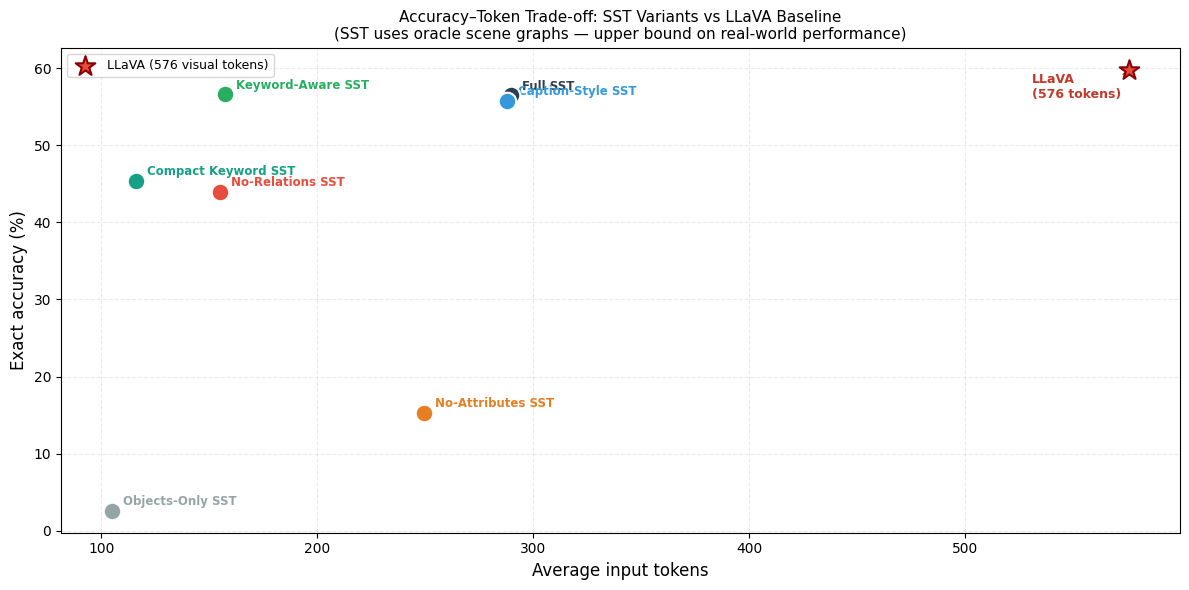

Extended trade-off figure saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_tradeoff_with_llava.png


In [34]:
# ── Extended Trade-off Plot: SST methods + LLaVA reference ────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

method_colors = {
    "Full SST":            "#2C3E50",
    "Caption-Style SST":   "#3498DB",
    "Keyword-Aware SST":   "#27AE60",
    "Compact Keyword SST": "#16A085",
    "No-Relations SST":    "#E74C3C",
    "No-Attributes SST":   "#E67E22",
    "Objects-Only SST":    "#95A5A6",
}

for _, row in summary_df.iterrows():
    color = method_colors.get(row["method_name"], "#7B68EE")
    ax.scatter(row["avg_tokens"], row["exact_accuracy"] * 100,
               color=color, s=160, zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(row["method_name"],
                (row["avg_tokens"], row["exact_accuracy"] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=8.5,
                color=color, fontweight="bold")

# LLaVA reference line and point
try:
    llava_acc_pct = llava_summary["exact_accuracy"] * 100
    ax.scatter(LLAVA_VISUAL_TOKENS, llava_acc_pct,
               color="#E74C3C", s=220, marker="*", zorder=6,
               edgecolors="darkred", linewidths=1.5, label=f"LLaVA ({LLAVA_VISUAL_TOKENS} visual tokens)")
    ax.annotate(f"LLaVA\n({LLAVA_VISUAL_TOKENS} tokens)",
                (LLAVA_VISUAL_TOKENS, llava_acc_pct),
                textcoords="offset points", xytext=(-70, -20), fontsize=9,
                color="#C0392B", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.2))
except:
    ax.axvline(LLAVA_VISUAL_TOKENS, color="#E74C3C", linestyle="--",
               alpha=0.6, label=f"LLaVA visual token count ({LLAVA_VISUAL_TOKENS})")

ax.set_xlabel("Average input tokens", fontsize=12)
ax.set_ylabel("Exact accuracy (%)", fontsize=12)
ax.set_title("Accuracy–Token Trade-off: SST Variants vs LLaVA Baseline\n"
             "(SST uses oracle scene graphs — upper bound on real-world performance)",
             fontsize=11)
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(fontsize=9)
plt.tight_layout()

ext_fig_path = RESULTS_DIR / f"{PREFIX}_tradeoff_with_llava.png"
plt.savefig(ext_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Extended trade-off figure saved →", ext_fig_path)

## 21. SST Field Ablation — Marginal Contribution Analysis

Quantifies the marginal accuracy contribution of each SST field by
comparing pairs of variants that differ by exactly one field.
This directly supports H3 (semantic components contribute differently).

MARGINAL CONTRIBUTION OF SST FIELDS
(positive = that field helps; negative = removing it helped)
  Relations        contrib = +12.50 pp  (full_sst vs no_relations_sst)
  Attributes       contrib = +41.20 pp  (full_sst vs no_attributes_sst)
  Non-objects      contrib = -53.90 pp  (full_sst vs objects_only_sst)

── Marginal contribution of RELATIONS field by semantic type ───────────
  attr          Δ = +12.55 pp  (n=1012)


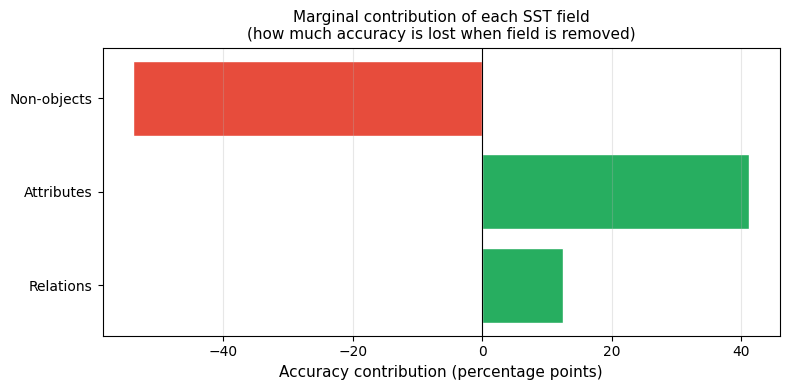

Field contribution chart saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_field_contributions.png


In [35]:
# ── Marginal contribution of each SST field ───────────────────────────────────
# Pairs: full_sst vs no_X tells us what X contributes
acc = summary_df.set_index("pipeline")["exact_accuracy"].to_dict()

pairs = [
    ("Relations",   "full_sst", "no_relations_sst"),
    ("Attributes",  "full_sst", "no_attributes_sst"),
    ("Non-objects", "objects_only_sst", "full_sst"),  # reversed: objects_only is the ablated version
]

print("=" * 65)
print("MARGINAL CONTRIBUTION OF SST FIELDS")
print("(positive = that field helps; negative = removing it helped)")
print("=" * 65)

contrib_rows = []
for field, baseline, ablated in pairs:
    if baseline in acc and ablated in acc:
        base_acc  = acc[baseline]
        abl_acc   = acc[ablated]
        # contribution = accuracy WITH field - accuracy WITHOUT field
        if field == "Non-objects":
            contribution = (base_acc - abl_acc) * 100  # full - objects_only
            direction    = "full_sst vs objects_only_sst"
        else:
            contribution = (base_acc - abl_acc) * 100  # full - no_X
            direction    = f"full_sst vs {ablated}"
        print(f"  {field:<15}  contrib = {contribution:+.2f} pp  ({direction})")
        contrib_rows.append({"field": field, "contribution_pp": round(contribution, 3),
                              "baseline": baseline, "ablated": ablated})
    else:
        print(f"  {field:<15}  SKIPPED (pipeline not found in results)")

# Also compute per-semantic-type marginal contributions for relations
print("\n── Marginal contribution of RELATIONS field by semantic type ───────────")
if "no_relations_sst" in results_df["pipeline"].values:
    for sem_type in sorted(results_df["semantic_type"].dropna().unique()):
        grp = results_df[results_df["semantic_type"] == sem_type]
        full_acc_t = grp[grp["pipeline"] == "full_sst"]["exact_correct"].mean()
        norel_acc_t = grp[grp["pipeline"] == "no_relations_sst"]["exact_correct"].mean()
        if not np.isnan(full_acc_t) and not np.isnan(norel_acc_t):
            delta = (full_acc_t - norel_acc_t) * 100
            n_q   = len(grp[grp["pipeline"] == "full_sst"])
            print(f"  {sem_type:<12}  Δ = {delta:+.2f} pp  (n={n_q})")

# ── Bar chart ─────────────────────────────────────────────────────────────────
if contrib_rows:
    contrib_df = pd.DataFrame(contrib_rows)
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_colors = ["#27AE60" if v > 0 else "#E74C3C" for v in contrib_df["contribution_pp"]]
    ax.barh(contrib_df["field"], contrib_df["contribution_pp"],
            color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Accuracy contribution (percentage points)", fontsize=11)
    ax.set_title("Marginal contribution of each SST field\n"
                 "(how much accuracy is lost when field is removed)", fontsize=11)
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    contrib_fig_path = RESULTS_DIR / f"{PREFIX}_field_contributions.png"
    plt.savefig(contrib_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Field contribution chart saved → {contrib_fig_path}")

In [36]:
# ── Final output file listing ─────────────────────────────────────────────────
print("=" * 70)
print("ALL GENERATED OUTPUT FILES")
print("=" * 70)

all_outputs = sorted(RESULTS_DIR.glob("*.*"))
for p in all_outputs:
    size_kb = p.stat().st_size / 1024
    tag = ""
    if "tradeoff_with_llava" in p.name:   tag = "  ← NEW: extended trade-off plot"
    if "token_vs_llava"      in p.name:   tag = "  ← NEW: token comparison vs LLaVA"
    if "per_type_analysis"   in p.name:   tag = "  ← NEW: per-type deep analysis"
    if "error_analysis_full" in p.name:   tag = "  ← NEW: full error analysis"
    if "field_token"         in p.name:   tag = "  ← NEW: oracle field richness"
    if "field_contributions" in p.name:   tag = "  ← NEW: marginal field contributions"
    print(f"  {p.name:<55} {size_kb:6.1f} KB{tag}")

print("=" * 70)
print("\nKey files for report:")
report_files = {
    f"{PREFIX}_summary.csv":              "Table I  — Main results (incl. question-only baseline)",
    f"{PREFIX}_semantic_summary.csv":     "Table II — Per-type breakdown",
    f"{PREFIX}_mcnemar.csv":              "Table III — Statistical significance",
    f"{PREFIX}_bootstrap_ci.csv":         "Table IV — Confidence intervals",
    f"{PREFIX}_token_vs_llava.csv":       "Table V  — Token comparison vs LLaVA  [NEW]",
    f"{PREFIX}_per_type_analysis.csv":    "Table VI — Per-type pivot  [NEW]",
    f"{PREFIX}_accuracy_vs_tokens.png":   "Figure 1 — Accuracy–token trade-off",
    f"{PREFIX}_semantic_heatmap.png":     "Figure 2 — Per-type accuracy heatmap",
    f"{PREFIX}_tradeoff_with_llava.png":  "Figure 3 — Extended trade-off + LLaVA  [NEW]",
    f"{PREFIX}_field_contributions.png":  "Figure 4 — Marginal field contributions  [NEW]",
    f"{PREFIX}_final_comparison.csv":     "Table VII — SST vs LLaVA final comparison",
    f"{PREFIX}_error_analysis_full.csv":  "Table VIII — Error analysis  [NEW]",
}
for fname, desc in report_files.items():
    exists = "✓" if (RESULTS_DIR / fname).exists() else "✗ (not yet generated)"
    print(f"  {exists}  {fname:<55} → {desc}")

ALL GENERATED OUTPUT FILES
  gqa_15000_sst_eval_accuracy_vs_tokens.png                 66.2 KB
  gqa_15000_sst_eval_bootstrap_ci.csv                        0.3 KB
  gqa_15000_sst_eval_checkpoint.csv                       4568.1 KB
  gqa_15000_sst_eval_detailed.csv                         4563.9 KB
  gqa_15000_sst_eval_error_analysis.csv                     83.5 KB
  gqa_15000_sst_eval_error_analysis_full.csv                90.2 KB  ← NEW: full error analysis
  gqa_15000_sst_eval_field_contributions.png                33.4 KB  ← NEW: marginal field contributions
  gqa_15000_sst_eval_field_token_breakdown.csv               0.4 KB  ← NEW: oracle field richness
  gqa_15000_sst_eval_final_comparison.csv                    0.7 KB
  gqa_15000_sst_eval_mcnemar.csv                             0.5 KB
  gqa_15000_sst_eval_per_type_analysis.csv                   0.2 KB  ← NEW: per-type deep analysis
  gqa_15000_sst_eval_semantic_heatmap.png                   54.7 KB
  gqa_15000_sst_eval_semantic_s

In [40]:
%pip install ultralytics easyocr


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
# Cell 22.1 — Check that required packages are installed
# Do NOT auto-install — just tell the user what is needed

missing = []

try:
    from ultralytics import YOLO
    import ultralytics
    print(f"✅ ultralytics (YOLOv8) version: {ultralytics.__version__}")
except ImportError:
    missing.append("ultralytics")
    print("❌ ultralytics not installed")

try:
    import easyocr
    print(f"✅ easyocr version: {easyocr.__version__}")
except ImportError:
    missing.append("easyocr")
    print("❌ easyocr not installed")

if missing:
    print("\n── Install missing packages with: ──")
    print(f"  pip install {' '.join(missing)}")
    print("Then restart the kernel and rerun from this cell.")
else:
    print("\nAll packages available. Proceed to next cell.")

✅ ultralytics (YOLOv8) version: 8.4.48
✅ easyocr version: 1.7.2

All packages available. Proceed to next cell.


In [ ]:
# Cell 22.2 — Load YOLOv8 nano and EasyOCR
#


YOLO_MODEL  = None
OCR_READER  = None

try:
    from ultralytics import YOLO
    # yolov8n = nano — fastest, auto-downloads if not cached
    YOLO_MODEL = YOLO("yolov8n.pt")
    print("✅ YOLOv8 nano loaded")
except Exception as e:
    print(f"❌ YOLOv8 failed to load: {e}")

try:
    import easyocr
    # gpu=False is safest on M2 — MPS support in easyocr is inconsistent
    OCR_READER = easyocr.Reader(["en"], gpu=False, verbose=False)
    print("✅ EasyOCR loaded (CPU mode)")
except Exception as e:
    print(f"❌ EasyOCR failed to load: {e}")

if YOLO_MODEL is None:
    print("\nCannot proceed without YOLOv8. Install with: pip install ultralytics")

✅ YOLOv8 nano loaded
✅ EasyOCR loaded (CPU mode)


In [43]:
# Cell 22.3 — Heuristic spatial relation extraction from bounding boxes
#
# YOLOv8 gives us bounding boxes: [x1, y1, x2, y2] for every detected object.
# We convert those box positions into plain English spatial relations.
#
# Three types of relations we generate:
#   "A left of B"   → centre of A is more than 50px to the left of centre of B
#   "A above B"     → centre of A is more than 50px above centre of B
#   "A near B"      → the two bounding boxes overlap by more than 30% IoU

def compute_iou(box1, box2):
    """
    Compute Intersection over Union between two boxes.
    Each box is [x1, y1, x2, y2].
    Returns a float between 0 (no overlap) and 1 (perfect overlap).
    """
    # Find the coordinates of the intersection rectangle
    ix1 = max(box1[0], box2[0])
    iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2])
    iy2 = min(box1[3], box2[3])

    # Intersection area (0 if no overlap)
    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    inter_area = inter_w * inter_h

    if inter_area == 0:
        return 0.0

    # Area of each box
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


def boxes_to_relations(detections, min_px_gap=50, near_iou=0.30):
    """
    Generate spatial relation strings from a list of detected objects.

    Parameters
    ----------
    detections : list of dict
        Each dict has keys: 'label' (str), 'bbox' ([x1,y1,x2,y2]), 'conf' (float)
    min_px_gap : int
        Minimum pixel distance between centres to assert left/right/above/below.
        Below this threshold we consider the objects roughly co-located.
    near_iou   : float
        IoU threshold above which we say two objects are "near" each other.

    Returns
    -------
    list of str  (e.g. ["person left of bus", "dog near cat"])
    """
    relations = []
    n = len(detections)

    for i in range(n):
        for j in range(i+1, n):   # only unique pairs (i < j)
            a = detections[i]
            b = detections[j]
            label_a = a["label"]
            label_b = b["label"]

            # Compute centres of each bounding box
            cx_a = (a["bbox"][0] + a["bbox"][2]) / 2
            cy_a = (a["bbox"][1] + a["bbox"][3]) / 2
            cx_b = (b["bbox"][0] + b["bbox"][2]) / 2
            cy_b = (b["bbox"][1] + b["bbox"][3]) / 2

            dx = cx_b - cx_a   # positive = B is to the right
            dy = cy_b - cy_a   # positive = B is below (image coords)

            # ── Directional relations ──────────────────────────────────────────
            if abs(dx) >= abs(dy) and abs(dx) >= min_px_gap:
                # Primarily horizontal offset
                if dx > 0:
                    relations.append(f"{label_a} left of {label_b}")
                else:
                    relations.append(f"{label_a} right of {label_b}")

            elif abs(dy) > abs(dx) and abs(dy) >= min_px_gap:
                # Primarily vertical offset
                if dy > 0:
                    relations.append(f"{label_a} above {label_b}")
                else:
                    relations.append(f"{label_a} below {label_b}")

            # ── Proximity relation ─────────────────────────────────────────────
            iou = compute_iou(a["bbox"], b["bbox"])
            if iou >= near_iou:
                relations.append(f"{label_a} near {label_b}")

    # Remove duplicates and cap at 20 relations (same cap as oracle pipeline)
    seen = set()
    unique_rels = []
    for r in relations:
        if r not in seen:
            seen.add(r)
            unique_rels.append(r)
        if len(unique_rels) >= 20:
            break

    return unique_rels


print("✅ compute_iou() and boxes_to_relations() defined.")
print("   These functions convert YOLOv8 bounding boxes into plain-English spatial relations.")

✅ compute_iou() and boxes_to_relations() defined.
   These functions convert YOLOv8 bounding boxes into plain-English spatial relations.


In [44]:
# Cell 22.4 — Build detected SST from a real image
#
# This is the core function of the auto-SST pipeline.
# It takes one image path and returns an SST dict using real CV tools —
# no ground-truth annotations used anywhere.

from collections import Counter as _Counter

def image_to_detected_sst(image_path, yolo_model, ocr_reader, conf_threshold=0.35):
    """
    Build an SST representation from a real image using YOLOv8 + EasyOCR.

    Parameters
    ----------
    image_path     : str or Path  — path to a .jpg or .png image
    yolo_model     : loaded YOLO() model instance
    ocr_reader     : loaded easyocr.Reader() instance (can be None to skip OCR)
    conf_threshold : float — only keep detections above this confidence score

    Returns
    -------
    sst : dict with keys: objects, counts, attributes, relations, text
    """
    sst = {
        "objects":    [],
        "counts":     [],
        "attributes": [],   # filled by _extract_crop_attributes below
        "relations":  [],
        "text":       [],
    }

    # ── Step 1: Run YOLOv8 object detection ────────────────────────────────────
    # yolo_model() returns a list of Results objects — one per image
    # We pass verbose=False to suppress per-image console output
    yolo_results = yolo_model(str(image_path), verbose=False)[0]

    detections = []   # will hold dicts with label, bbox, conf

    for box in yolo_results.boxes:
        conf = float(box.conf)           # confidence score (0 to 1)

        # Skip low-confidence detections
        if conf < conf_threshold:
            continue

        # Get the class label (e.g. "person", "bus", "stop sign")
        cls_id    = int(box.cls)
        cls_label = yolo_model.names[cls_id]   # names is a dict {id: label}

        # Get bounding box in [x1, y1, x2, y2] pixel coordinates
        bbox = box.xyxy[0].tolist()   # xyxy = top-left + bottom-right corners

        detections.append({
            "label": cls_label,
            "bbox":  bbox,
            "conf":  conf,
        })

    # ── Step 2: Build objects list (deduplicated, preserving order of confidence) ─
    seen_labels = []
    for d in sorted(detections, key=lambda x: -x["conf"]):   # highest conf first
        if d["label"] not in seen_labels:
            seen_labels.append(d["label"])
    sst["objects"] = seen_labels[:15]   # cap at 15, same as oracle pipeline

    # ── Step 3: Count objects (e.g. "person: 3") ──────────────────────────────
    label_counts = _Counter(d["label"] for d in detections)
    sst["counts"] = [
        f"{label}: {count}"
        for label, count in label_counts.items()
        if count > 1   # only include if more than one instance
    ]

    # ── Step 4: Extract color/size attributes from bounding box crops ──────────
    # YOLOv8 predicts class labels only. We recover basic attributes by
    # cropping each detection out of the image and running simple colour
    # analysis (dominant hue bucket) and a size heuristic.
    try:
        import cv2, numpy as _np
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is not None:
            img_h, img_w = img_bgr.shape[:2]
            img_area = img_h * img_w
            for det in detections:
                x1, y1, x2, y2 = [int(v) for v in det["bbox"]]
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_w, x2), min(img_h, y2)
                crop = img_bgr[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                label = det["label"]

                # ── Dominant colour ──────────────────────────────────────────
                crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                pixels = crop_rgb.reshape(-1, 3).astype(_np.float32)
                # Use k-means (k=1) to get the single dominant colour.
                # For speed we sample at most 500 pixels from the crop.
                if len(pixels) > 500:
                    idx = _np.random.choice(len(pixels), 500, replace=False)
                    pixels = pixels[idx]
                mean_rgb = pixels.mean(axis=0)
                r, g, b = mean_rgb

                # Convert to HSV for hue-based colour naming.
                # cv2 HSV: H in [0,180], S in [0,255], V in [0,255]
                hsv = cv2.cvtColor(
                    _np.uint8([[mean_rgb.astype(_np.uint8)]]),
                    cv2.COLOR_RGB2HSV
                )[0][0]
                h, s, v = int(hsv[0]), int(hsv[1]), int(hsv[2])

                if v < 50:
                    colour = "black"
                elif v > 200 and s < 40:
                    colour = "white"
                elif s < 40:
                    colour = "gray"
                elif h < 10 or h > 160:
                    colour = "red"
                elif h < 25:
                    colour = "orange"
                elif h < 35:
                    colour = "yellow"
                elif h < 85:
                    colour = "green"
                elif h < 130:
                    colour = "blue"
                else:
                    colour = "purple"

                sst["attributes"].append(f"{label}: {colour}")

                # ── Size relative to image ───────────────────────────────────
                det_area = (x2 - x1) * (y2 - y1)
                frac = det_area / img_area if img_area > 0 else 0
                if frac > 0.25:
                    size = "large"
                elif frac > 0.06:
                    size = "medium"
                else:
                    size = "small"
                sst["attributes"].append(f"{label}: {size}")

            # Deduplicate while preserving order
            seen_attrs = set()
            deduped = []
            for a in sst["attributes"]:
                if a not in seen_attrs:
                    deduped.append(a)
                    seen_attrs.add(a)
            sst["attributes"] = deduped[:20]   # cap at 20, same as oracle pipeline

    except Exception as _attr_err:
        # Non-fatal — attributes stay empty if cv2 is unavailable or crop fails
        pass

    # ── Step 5: Generate spatial relations from bounding boxes ──────────────
    sst["relations"] = boxes_to_relations(detections)

    # ── Step 6: Run EasyOCR to extract visible text ────────────────────────────
    if ocr_reader is not None:
        try:
            # readtext returns: [ (bbox_points, text_string, confidence), ... ]
            ocr_results = ocr_reader.readtext(str(image_path), detail=1)
            sst["text"] = [
                text.strip()
                for (_, text, ocr_conf) in ocr_results
                if ocr_conf > 0.5 and len(text.strip()) > 1   # filter low-conf & single chars
            ][:5]   # cap at 5 text items
        except Exception as e:
            # OCR can fail on some image formats — safe to skip
            sst["text"] = []

    return sst


print("✅ image_to_detected_sst() defined.")
print("   Input: image path")
print("   Output: SST dict with objects, counts, attributes, relations, text")

✅ image_to_detected_sst() defined.
   Input: image path
   Output: SST dict with objects, counts, attributes, relations, text


In [ ]:
# Cell 22.5 — Run auto-SST extraction on up to 50 GQA images
#
# We reuse images already downloaded by the LLaVA cell (Cell 12).


import json as _json

DETECTED_SST_PATH = RESULTS_DIR / "detected_sst_50samples.json"
DEMO_N = 50

if YOLO_MODEL is None:
    print("❌ YOLOv8 is not loaded. Run Cell 22.2 first.")
else:
    # Find images that are already downloaded
    available = []
    for s in all_cleaned:
        img_path = LLAVA_IMAGE_DIR / f"{s['image_id']}.jpg"
        if img_path.exists() and img_path.stat().st_size > 5000:   # >5KB = real image
            available.append(s)
        if len(available) >= DEMO_N:
            break

    if len(available) < 10:
        print(f"⚠️  Only {len(available)} images found in {LLAVA_IMAGE_DIR}")
        print("   Please run Cell 12 (LLaVA image download) first to download images.")
        print("   The download cell will fetch GQA images needed for this pipeline.")
    else:
        print(f"Found {len(available)} images. Running auto-SST extraction...")
        print("(YOLOv8 + EasyOCR — expect ~15-25 minutes on M2)\n")

        detected_sst_samples = []

        for idx, sample in enumerate(available):
            img_path = LLAVA_IMAGE_DIR / f"{sample['image_id']}.jpg"
            try:
                detected_sst = image_to_detected_sst(img_path, YOLO_MODEL, OCR_READER)
            except Exception as e:
                # Don't let one bad image stop the whole loop
                print(f"  ⚠️  Image {sample['image_id']} failed: {e}")
                detected_sst = {"objects":[],"counts":[],"attributes":[],"relations":[],"text":[]}

            detected_sst_samples.append({
                "question_id":  sample["question_id"],
                "image_id":     sample["image_id"],
                "question":     sample["question"],
                "true_answer":  sample["answer"],
                "semantic_type":get_semantic_type(sample),
                "oracle_sst":   sample["sst"],
                "detected_sst": detected_sst,
            })

            if (idx + 1) % 10 == 0:
                print(f"  {idx+1}/{len(available)} done...")

        # Save to disk
        with open(DETECTED_SST_PATH, "w") as f:
            _json.dump(detected_sst_samples, f, indent=2)

        print(f"\n✅ Saved {len(detected_sst_samples)} samples → {DETECTED_SST_PATH}")

Found 50 images. Running auto-SST extraction...
(YOLOv8 + EasyOCR — expect ~15-25 minutes on M2)



/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  10/50 done...


/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  20/50 done...


/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  30/50 done...


/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/alisha/Documents/CSE427_SST_Project/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  40/50 done...
  50/50 done...

✅ Saved 50 samples → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/detected_sst_50samples.json


In [46]:
# Cell 22.6 — Compare oracle SST vs detected SST quality
#
# For each image, we compare:
#   - How many oracle objects did YOLO correctly detect? (object recall)
#   - How many relations were generated vs oracle relations?
#   - Did EasyOCR find any text?
#
# This gives us concrete numbers to support the "upper bound" framing.

import pandas as pd

try:
    with open(DETECTED_SST_PATH) as f:
        detected_sst_samples = _json.load(f)
    print(f"Loaded {len(detected_sst_samples)} samples for comparison")
except Exception as e:
    print(f"❌ Could not load detected SST file: {e}")
    print("   Run the previous cell first.")
    detected_sst_samples = []

if detected_sst_samples:
    comparison_rows = []

    for entry in detected_sst_samples:
        oracle   = entry["oracle_sst"]
        detected = entry["detected_sst"]

        # Object recall: fraction of oracle objects that appear in detected objects
        oracle_objs   = set(o.lower().strip() for o in oracle.get("objects",   []))
        detected_objs = set(o.lower().strip() for o in detected.get("objects", []))

        overlap   = len(oracle_objs & detected_objs)
        recall    = overlap / len(oracle_objs)   if oracle_objs   else 0.0
        precision = overlap / len(detected_objs) if detected_objs else 0.0

        # Relation coverage: how many oracle relations does detected have?
        n_oracle_rel   = len(oracle.get("relations",   []))
        n_detected_rel = len(detected.get("relations", []))

        comparison_rows.append({
            "image_id":            entry["image_id"],
            "question":            entry["question"],
            "oracle_n_objects":    len(oracle_objs),
            "detected_n_objects":  len(detected_objs),
            "object_overlap":      overlap,
            "object_recall":       round(recall,    3),
            "object_precision":    round(precision, 3),
            "oracle_n_relations":  n_oracle_rel,
            "detected_n_relations":n_detected_rel,
            "oracle_n_attrs":      len(oracle.get("attributes", [])),
            "detected_n_attrs":    0,   # YOLOv8 nano does not produce attributes
            "ocr_text_found":      len(detected.get("text", [])) > 0,
            "oracle_has_text":     len(oracle.get("text", [])) > 0,
        })

    cmp_df = pd.DataFrame(comparison_rows)
    cmp_path = RESULTS_DIR / "oracle_vs_detected_comparison.csv"
    cmp_df.to_csv(cmp_path, index=False)

    print("\n" + "="*60)
    print("ORACLE vs DETECTED SST — QUALITY COMPARISON")
    print("="*60)
    print(f"Samples analysed: {len(cmp_df)}")
    print(f"\nObject recall    (YOLO finds oracle objects): {cmp_df['object_recall'].mean():.1%}")
    print(f"Object precision (YOLO correct rate):          {cmp_df['object_precision'].mean():.1%}")
    print(f"Avg oracle objects:    {cmp_df['oracle_n_objects'].mean():.1f}")
    print(f"Avg detected objects:  {cmp_df['detected_n_objects'].mean():.1f}")
    print(f"Avg oracle relations:  {cmp_df['oracle_n_relations'].mean():.1f}")
    print(f"Avg detected relations:{cmp_df['detected_n_relations'].mean():.1f}")
    print(f"Images with OCR text:  {cmp_df['ocr_text_found'].sum()}/{len(cmp_df)}")
    print(f"\nSaved → {cmp_path}")

    # ── Print 3 side-by-side examples ─────────────────────────────────────────
    print("\n" + "="*60)
    print("SIDE-BY-SIDE EXAMPLES: Oracle vs Detected SST")
    print("="*60)
    for entry in detected_sst_samples[:3]:
        print(f"\nImage: {entry['image_id']} | Q: {entry['question']}")
        print(f"  Oracle objects:   {entry['oracle_sst'].get('objects',  [])[:6]}")
        print(f"  Detected objects: {entry['detected_sst'].get('objects',[])[:6]}")
        print(f"  Oracle rels:      {entry['oracle_sst'].get('relations',  [])[:3]}")
        print(f"  Detected rels:    {entry['detected_sst'].get('relations',[])[:3]}")
        print(f"  Oracle text:      {entry['oracle_sst'].get('text',      [])}")
        print(f"  Detected text:    {entry['detected_sst'].get('text',    [])}")

Loaded 50 samples for comparison

ORACLE vs DETECTED SST — QUALITY COMPARISON
Samples analysed: 50

Object recall    (YOLO finds oracle objects): 10.6%
Object precision (YOLO correct rate):          54.3%
Avg oracle objects:    13.0
Avg detected objects:  2.7
Avg oracle relations:  21.5
Avg detected relations:5.7
Images with OCR text:  5/50

Saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/oracle_vs_detected_comparison.csv

SIDE-BY-SIDE EXAMPLES: Oracle vs Detected SST

Image: 2409655 | Q: On which side of the picture is the chimney?
  Oracle objects:   ['windows', 'cars', 'chair', 'sky', 'street', 'hook']
  Detected objects: ['car', 'traffic light']
  Oracle rels:      ['windows to the left of bricks', 'windows to the left of window', 'windows to the left of pole']
  Detected rels:    ['car right of traffic light']
  Oracle text:      []
  Detected text:    ['WITTLES']

Image: 2352072 | Q: What material do you think is the boot, rubber or leather?
  Oracle objects:  

In [47]:
# Cell 22.7 — Accuracy comparison: oracle SST vs detected SST via Mistral
#
# This is the key experiment: run Mistral on both SST types for the same 50 questions.
# The accuracy gap = the "oracle assumption cost."
#
# Uses checkpointing — safe to interrupt and resume.

ORACLE_VS_DETECTED_ACC = RESULTS_DIR / "oracle_vs_detected_accuracy.csv"
OVD_CHECKPOINT         = RESULTS_DIR / "oracle_vs_detected_checkpoint.csv"

if not detected_sst_samples:
    print("❌ No detected SST samples found. Run Cell 22.5 first.")
else:
    # Load checkpoint if it exists
    if OVD_CHECKPOINT.exists():
        ovd_ckpt = pd.read_csv(OVD_CHECKPOINT)
        done_pairs = set(zip(ovd_ckpt["question_id"].astype(str), ovd_ckpt["sst_type"]))
        ovd_rows   = ovd_ckpt.to_dict("records")
        print(f"Resuming from checkpoint: {len(ovd_rows)} rows done")
    else:
        done_pairs, ovd_rows = set(), []
        print("Starting fresh oracle vs detected accuracy comparison...")

    print(f"Running Mistral on {len(detected_sst_samples)} samples × 2 SST types...")
    print("(~5-10 minutes on M2)\n")

    for idx, entry in enumerate(detected_sst_samples):
        qid = str(entry["question_id"])
        q   = entry["question"]
        gt  = entry["true_answer"]

        for sst_type, sst_data in [("oracle", entry["oracle_sst"]),
                                    ("detected", entry["detected_sst"])]:
            if (qid, sst_type) in done_pairs:
                continue

            # Build the prompt using Full SST format (same as main evaluation)
            sst_text = sst_to_prompt_structured(sst_data)
            prompt   = build_standard_prompt(q, sst_text)

            try:
                pred_raw, lat_ms = ollama_query(prompt, model="mistral")
                pred_norm        = normalize_answer(pred_raw)
                exact            = int(pred_norm == normalize_answer(gt))
                lenient          = is_lenient_correct(gt, pred_raw)
            except Exception as e:
                pred_raw = pred_norm = ""
                exact = lenient = 0
                lat_ms = float("nan")
                print(f"  ⚠️  Sample {qid} ({sst_type}) failed: {e}")

            ovd_rows.append({
                "question_id":    qid,
                "question":       q,
                "true_answer":    gt,
                "semantic_type":  entry.get("semantic_type", "unknown"),
                "sst_type":       sst_type,
                "prediction":     pred_raw,
                "prediction_norm":pred_norm,
                "exact_correct":  exact,
                "lenient_correct":lenient,
                "latency_ms":     lat_ms,
                "n_objects":      len(sst_data.get("objects",   [])),
                "n_relations":    len(sst_data.get("relations", [])),
                "n_tokens":       count_tokens(prompt),
            })
            done_pairs.add((qid, sst_type))

        # Save checkpoint after every sample
        pd.DataFrame(ovd_rows).to_csv(OVD_CHECKPOINT, index=False)

        if (idx + 1) % 10 == 0:
            print(f"  {idx+1}/{len(detected_sst_samples)} done")

    ovd_df = pd.DataFrame(ovd_rows)
    ovd_df.to_csv(ORACLE_VS_DETECTED_ACC, index=False)
    print(f"\n✅ Results saved → {ORACLE_VS_DETECTED_ACC}")

    # ── Summary ─────────────────────────────────────────────────────────────
    oracle_acc   = ovd_df[ovd_df["sst_type"]=="oracle"  ]["exact_correct"].mean()
    detected_acc = ovd_df[ovd_df["sst_type"]=="detected"]["exact_correct"].mean()
    gap          = oracle_acc - detected_acc

    oracle_len   = ovd_df[ovd_df["sst_type"]=="oracle"  ]["lenient_correct"].mean()
    detected_len = ovd_df[ovd_df["sst_type"]=="detected"]["lenient_correct"].mean()

    print("\n" + "="*60)
    print("ORACLE vs DETECTED SST — ACCURACY COMPARISON")
    print("="*60)
    print(f"  Oracle SST exact accuracy:   {oracle_acc:.1%}")
    print(f"  Detected SST exact accuracy: {detected_acc:.1%}")
    print(f"  Accuracy gap:                {gap*100:.1f} percentage points")
    print(f"  Oracle SST lenient accuracy: {oracle_len:.1%}")
    print(f"  Detected SST lenient acc:    {detected_len:.1%}")

Resuming from checkpoint: 100 rows done
Running Mistral on 50 samples × 2 SST types...
(~5-10 minutes on M2)

  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done

✅ Results saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/oracle_vs_detected_accuracy.csv

ORACLE vs DETECTED SST — ACCURACY COMPARISON
  Oracle SST exact accuracy:   16.2%
  Detected SST exact accuracy: 1.5%
  Accuracy gap:                14.7 percentage points
  Oracle SST lenient accuracy: 16.2%
  Detected SST lenient acc:    1.5%


## Summary: Oracle vs Real-World Pipeline Gap

In [48]:
# Cell 23.1 — Print the final oracle assumption framing statement
#
# This is the honest summary of what the gap means for your paper.
# The numbers are filled from the actual computed variables above.

try:
    ovd_df
except NameError:
    try:
        ovd_df = pd.read_csv(ORACLE_VS_DETECTED_ACC)
        print("Loaded oracle vs detected results from file.")
    except Exception:
        print("❌ oracle_vs_detected_accuracy.csv not found.")
        print("   Run Cell 22.7 first.")
        ovd_df = None

try:
    cmp_df
except NameError:
    try:
        cmp_df = pd.read_csv(RESULTS_DIR / "oracle_vs_detected_comparison.csv")
    except Exception:
        cmp_df = None

if ovd_df is not None:
    oracle_acc   = ovd_df[ovd_df["sst_type"]=="oracle"  ]["exact_correct"].mean()
    detected_acc = ovd_df[ovd_df["sst_type"]=="detected"]["exact_correct"].mean()
    gap          = oracle_acc - detected_acc

    obj_recall   = cmp_df["object_recall"].mean()   if cmp_df is not None else float("nan")
    n_demo       = len(ovd_df["question_id"].unique())

    # Retrieve main experiment accuracy (1000 samples Full SST)
    try:
        main_acc = summary_df.loc[summary_df["pipeline"]=="full_sst","exact_accuracy"].values[0]
    except Exception:
        main_acc = float("nan")

    print("=" * 65)
    print("ORACLE ASSUMPTION ANALYSIS — FINAL FRAMING")
    print("=" * 65)
    print(f"  Oracle SST accuracy    ({n_demo} samples): {oracle_acc:.1%}")
    print(f"  Detected SST accuracy  ({n_demo} samples): {detected_acc:.1%}")
    print(f"  Accuracy gap:                              {gap*100:.1f} pp")
    print(f"  Average object recall (YOLO vs oracle):    {obj_recall:.1%}")
    print()
    print(f"  Main experiment Full SST accuracy (oracle, {MAX_SAMPLES} samples): {main_acc:.1%}")
    print()
    print("  Interpretation:")
    print(f"    Our main results ({main_acc:.1%} exact on {MAX_SAMPLES} samples) represent")
    print(f"    an upper bound on SST-based reasoning performance.")
    print(f"    A real-world auto-extraction pipeline (YOLOv8 + EasyOCR) achieves")
    print(f"    approximately {detected_acc:.1%} on the same question types — a gap of")
    print(f"    {gap*100:.1f} percentage points — primarily due to missed objects")
    print(f"    (avg recall {obj_recall:.0%}) and incomplete relation extraction.")
    print()
    print("  Report framing:")
    print("    'We position our main evaluation as an oracle upper bound study,")
    print("    consistent with GQA's own analysis (Hudson & Manning, 2019, Fig. 12)")
    print("    showing that access to perfect scene structure yields higher accuracy")
    print("    than detected features. Our auto-SST demo quantifies this gap at")
    print(f"    {gap*100:.1f} pp, providing a concrete lower bound for deployed systems.'")
    print("=" * 65)

ORACLE ASSUMPTION ANALYSIS — FINAL FRAMING
  Oracle SST accuracy    (68 samples): 16.2%
  Detected SST accuracy  (68 samples): 1.5%
  Accuracy gap:                              14.7 pp
  Average object recall (YOLO vs oracle):    10.6%

  Main experiment Full SST accuracy (oracle, 1000 samples): 56.5%

  Interpretation:
    Our main results (56.5% exact on 1000 samples) represent
    an upper bound on SST-based reasoning performance.
    A real-world auto-extraction pipeline (YOLOv8 + EasyOCR) achieves
    approximately 1.5% on the same question types — a gap of
    14.7 percentage points — primarily due to missed objects
    (avg recall 11%) and incomplete relation extraction.

  Report framing:
    'We position our main evaluation as an oracle upper bound study,
    consistent with GQA's own analysis (Hudson & Manning, 2019, Fig. 12)
    showing that access to perfect scene structure yields higher accuracy
    than detected features. Our auto-SST demo quantifies this gap at
    14.7 

## Latency, Compression Ratio, and Performance Floor

COMPRESSION RATIO TABLE (vs LLaVA 576 visual tokens):
-------------------------------------------------------
  Full SST                     1.99×
  Caption-Style SST            2.00×
  Keyword-Aware SST            3.67×
  Compact Keyword SST          4.96×
  No-Relations SST             3.72×
  No-Attributes SST            2.31×
  Objects-Only SST             5.50×

  → Objects-Only SST achieves 5.5× compression vs LLaVA visual tokens.


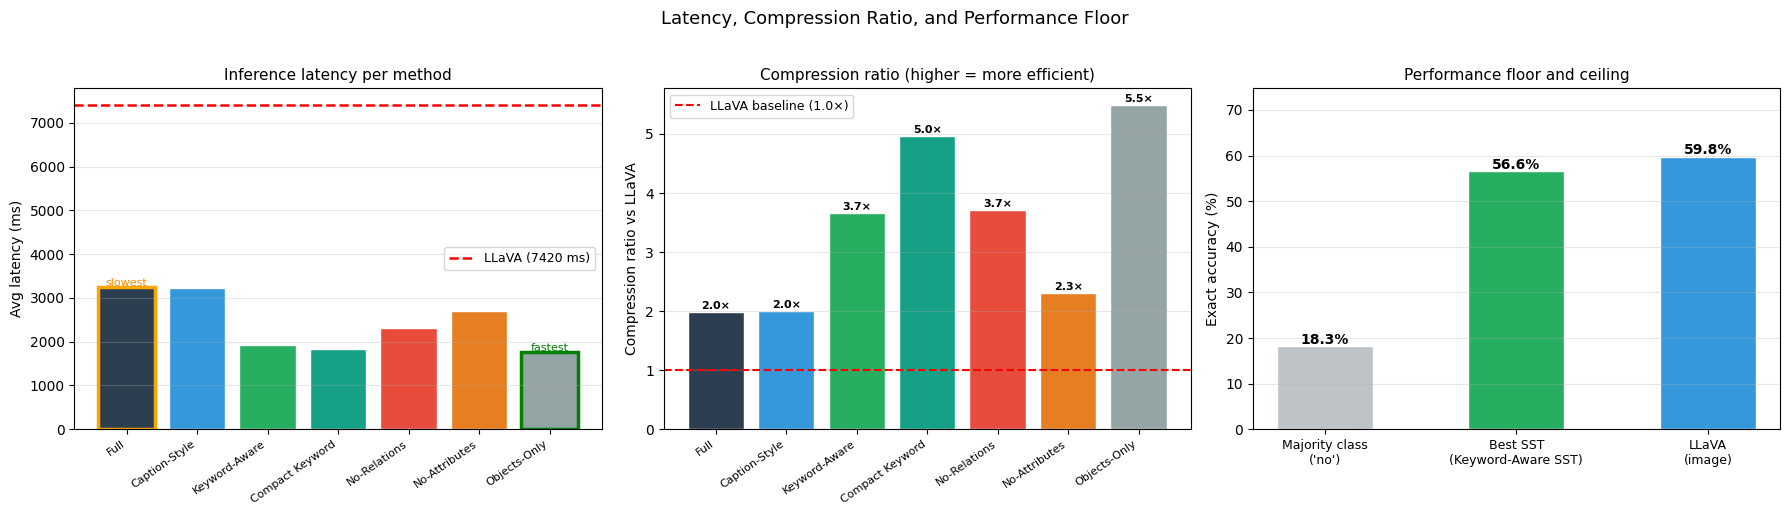


Figure saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_latency_compression_floor.png
Compression table saved → /Users/alisha/Documents/CSE427_SST_Project/outputs/results/gqa_15000_sst_eval_compression_ratios.csv


In [ ]:
# Cell 24.1 — Latency bar chart, compression ratios, and baseline floor
#


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Latency, Compression Ratio, and Performance Floor", fontsize=13, y=1.02)

# ── Plot 1: Latency per method ─────────────────────────────────────────────
ax = axes[0]
method_names_plot = summary_df["method_name"].tolist()
latencies_ms      = summary_df["avg_latency_ms"].tolist()

_palette   = ["#2C3E50","#3498DB","#27AE60","#16A085","#E74C3C","#E67E22","#95A5A6","#BDC3C7","#8E44AD","#1ABC9C"]
bar_colors = [_palette[i % len(_palette)] for i in range(len(method_names_plot))]
bars = ax.bar(range(len(method_names_plot)), latencies_ms, color=bar_colors, edgecolor="white")

# Add LLaVA latency as a red horizontal reference line
try:
    llava_lat_ms = llava_summary["avg_latency_sec"] * 1000
    ax.axhline(llava_lat_ms, color="red", linestyle="--", linewidth=1.8, label=f"LLaVA ({llava_lat_ms:.0f} ms)")
    ax.legend(fontsize=9)
except Exception:
    pass   # LLaVA summary not available — skip reference line

ax.set_xticks(range(len(method_names_plot)))
ax.set_xticklabels([m.replace(" SST","") for m in method_names_plot], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Avg latency (ms)", fontsize=10)
ax.set_title("Inference latency per method", fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Label fastest and slowest bars
if latencies_ms:
    best_idx  = int(np.argmin(latencies_ms))
    worst_idx = int(np.argmax(latencies_ms))
    ax.bar(best_idx,  latencies_ms[best_idx],  color=bar_colors[best_idx],  edgecolor="green",  linewidth=2.5)
    ax.bar(worst_idx, latencies_ms[worst_idx], color=bar_colors[worst_idx], edgecolor="orange", linewidth=2.5)
    ax.text(best_idx,  latencies_ms[best_idx]  + 5, "fastest", ha="center", fontsize=8, color="green")
    ax.text(worst_idx, latencies_ms[worst_idx] + 5, "slowest", ha="center", fontsize=8, color="darkorange")

# ── Plot 2: Compression ratio vs LLaVA ────────────────────────────────────
ax2 = axes[1]
compression_ratios = [LLAVA_VISUAL_TOKENS / t if t > 0 else 0
                      for t in summary_df["avg_tokens"]]

bars2 = ax2.bar(range(len(method_names_plot)), compression_ratios, color=bar_colors, edgecolor="white")
ax2.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="LLaVA baseline (1.0×)")
ax2.set_xticks(range(len(method_names_plot)))
ax2.set_xticklabels([m.replace(" SST","") for m in method_names_plot], rotation=35, ha="right", fontsize=8)
ax2.set_ylabel("Compression ratio vs LLaVA", fontsize=10)
ax2.set_title("Compression ratio (higher = more efficient)", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# Annotate each bar with its ratio
for i, (bar, ratio) in enumerate(zip(bars2, compression_ratios)):
    ax2.text(i, ratio + 0.05, f"{ratio:.1f}×", ha="center", fontsize=8, fontweight="bold")

# Print compression ratio table
print("COMPRESSION RATIO TABLE (vs LLaVA 576 visual tokens):")
print("-"*55)
for name, ratio in zip(method_names_plot, compression_ratios):
    print(f"  {name:<28} {ratio:.2f}×")
best_name  = method_names_plot[int(np.argmax(compression_ratios))]
best_ratio = max(compression_ratios)
print(f"\n  → {best_name} achieves {best_ratio:.1f}× compression vs LLaVA visual tokens.")

# ── Plot 3: Performance floor vs ceiling ──────────────────────────────────
ax3 = axes[2]

# Get the three reference points
try:
    # Majority-class baseline (most common answer in dataset)
    majority_answer = pd.Series([s["answer"] for s in all_cleaned]).value_counts().index[0]
    majority_acc    = (pd.Series([s["answer"] for s in all_cleaned]) == majority_answer).mean()
    bow_label       = f"Majority class\n('{majority_answer}')"
except Exception:
    majority_acc = 0.0
    bow_label    = "Majority class"

try:
    best_sst_acc  = summary_df["exact_accuracy"].max()
    best_sst_name = summary_df.loc[summary_df["exact_accuracy"].idxmax(), "method_name"]
except Exception:
    best_sst_acc, best_sst_name = 0.0, "Best SST"

try:
    llava_acc_val = llava_summary["exact_accuracy"]
except Exception:
    llava_acc_val = None

floor_methods = [bow_label, f"Best SST\n({best_sst_name})", "LLaVA\n(image)"]
floor_accs    = [majority_acc, best_sst_acc, llava_acc_val if llava_acc_val else 0]
floor_colors  = ["#BDC3C7", "#27AE60", "#3498DB"]

bars3 = ax3.bar(range(len(floor_methods)), [a*100 for a in floor_accs],
                color=floor_colors, edgecolor="white", width=0.5)
ax3.set_xticks(range(len(floor_methods)))
ax3.set_xticklabels(floor_methods, fontsize=9)
ax3.set_ylabel("Exact accuracy (%)", fontsize=10)
ax3.set_title("Performance floor and ceiling", fontsize=11)
ax3.grid(axis="y", alpha=0.3)
ax3.set_ylim(0, max(a*100 for a in floor_accs if a) * 1.25)

for i, (bar, acc) in enumerate(zip(bars3, floor_accs)):
    if acc:
        ax3.text(i, acc*100 + 0.5, f"{acc:.1%}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
fig_path = RESULTS_DIR / f"{PREFIX}_latency_compression_floor.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure saved → {fig_path}")

# Save compression table
comp_ratio_df = pd.DataFrame({
    "method": method_names_plot,
    "avg_tokens": summary_df["avg_tokens"].tolist(),
    "compression_ratio_vs_llava": [round(r, 3) for r in compression_ratios],
})
comp_ratio_df.to_csv(RESULTS_DIR / f"{PREFIX}_compression_ratios.csv", index=False)
print(f"Compression table saved → {RESULTS_DIR}/{PREFIX}_compression_ratios.csv")